# 1 практическое задание. Полносвязная нейронная сеть на `numpy`.

## Практикум на ЭВМ для 317 группы, весна 2021

#### Фамилия, имя: 

Дата выдачи: <span style="color:red">__17 февраля 03:00__</span>.

Мягкий дедлайн: <span style="color:red">__10 марта 23:59__</span>.

Стоимость: __10 баллов__ (основная часть заданий) + __3 балла__ (дополнительные задания).

<span style="color:red">__В ноутбуке все клетки должны выполняться без ошибок при последовательном их выполнении.__</span>

In [134]:
import numpy as np
from tqdm import trange
from tqdm import tqdm

## Теоретическая часть (3 балла)

В этом блоке вам нужно решить 3 задания.

### Задание 1. Градиенты для слоя Batch normalization (1.5 балла)

Рассмотрим слой Batch normalization. Пусть на вход этого слоя был подан батч из $n$ объектов, при этом у всех объектов по 1 признаку. Представим вход BN слоя в виде $X \in \mathbb{R}^{n \times 1}$.

Тогда в этом слое производятся следующие вычисления:

$$ \mu = \frac1n \sum_{i=1}^{n} X_i $$

$$ \sigma^2 = \frac1n \sum_{i=1}^{n} \left( X_i - \mu \right) ^2 $$

$$ \tilde{y_i} = \frac{X_i - \mu}{\sqrt{\sigma^2 + \varepsilon}} $$

$$ y_i = \gamma \tilde{y_i} + \delta $$

Выходом BN слоя является $y_i$, а $\gamma$ и $\delta$ в нем — параметры, которые подбираются во время обучения вместе с другими параметрами нейронной сети (наряду, например, с весами линейного слоя).

Рассмотрим нейронную сеть, в которой есть BN слой. Предположим, что вычисления в нейронной завершаются подсчетом функции потерь $\mathcal{L}$. Пусть мы выполнили прямой проход по нейронной сети и сейчас делаем обратный проход с помощью метода обратного распространения ошибки. Пусть BN слою пришел градиент функции потерь по выходу BN слоя ($\nabla_{y} \mathcal{L}$).

В этом задании вам нужно записать вычисление градиента функции потерь по параметрам слоя BN $\gamma$ и $\delta$ ($\nabla_{\gamma} \mathcal{L}$, $\nabla_{\delta} \mathcal{L}$) через $\nabla_{y} \mathcal{L}$, а также вам нужно записать вычисление градиента функции потерь по входу слоя BN $X$ ($\nabla_{X} \mathcal{L}$) через $\nabla_{y} \mathcal{L}$.

Хочу заметить, в данном задании мы рассматриваем объекты всего с 1 признаком, чтобы упростить выкладки.

__Ваше решение:__

Обозначим за $\vec{1}$ вектор, полностью состоящий из $1$, а за $E$ $-$ матрицу, полностью состоящую из $1$. Размеры $\vec{1}$ и $E$ определяются из контекста. Следовательно:
* $\vec{1}^T\cdot\vec{1}=n, \; \vec{1} \in \mathbb{R}^n$.
* $\vec{1}\cdot\vec{1}^T=E, \; \vec{1} \in \mathbb{R}^n, \; E \in \mathbb{R}^{n \times n}$.

Преобразуем начальные формулы в векторный вид:

$$ \mu = \frac1n \vec{1}^T X $$

$$ \sigma^2 = \frac1n \langle X-\mu\vec{1}, X-\mu\vec{1} \rangle $$

$$ \tilde{y} = \frac{1}{\sqrt{\sigma^2 + \varepsilon}} \left( X-\mu\vec{1} \right) $$

$$y = \gamma \tilde{y} + \delta \vec{1} \;\;(\gamma, \delta \in \mathbb{R})$$

* $d\mathcal{L} = \langle \nabla_{y} \mathcal{L}, dy \rangle = \nabla_{y} \mathcal{L}^Tdy$

* $dy = d(\gamma\tilde{y} + \delta \vec{1}) = d\gamma \cdot \tilde{y} + \gamma \cdot d\tilde{y} + d\delta \cdot \vec{1} \Rightarrow d\mathcal{L} = \nabla_{y} \mathcal{L}^T\tilde{y}d\gamma + \nabla_{y} \mathcal{L}^T\gamma d\tilde{y} + \nabla_{y} \mathcal{L}^T\vec{1}d\delta$

Значит, $\nabla_{\gamma} \mathcal{L} = \tilde{y}^T\nabla_{y} \mathcal{L} = \langle \tilde{y}, \nabla_{y} \mathcal{L} \rangle, \; \nabla_{\delta} \mathcal{L} = \vec{1}^T\nabla_{y} \mathcal{L} = \langle \vec{1}, \nabla_{y} \mathcal{L} \rangle$

Теперь найдём $\nabla_{X} \mathcal{L}$.

Рассмотрим $\nabla_{y} \mathcal{L}^T\gamma d\tilde{y}$, в нём:

* $d\tilde{y} = d\left(\frac{1}{\sqrt{\sigma^2 + \varepsilon}} \left( X-\mu\vec{1} \right) \right) = d\left(\frac{1}{\sqrt{\sigma^2 + \varepsilon}}\right)\cdot\left( X-\mu\vec{1} \right) + \left(\frac{1}{\sqrt{\sigma^2 + \varepsilon}}\right)\cdot d \left( X-\mu\vec{1} \right) = 
%
\left\{
d\left(\frac{1}{\sqrt{\sigma^2 + \varepsilon}}\right) = -\frac{1}{2\left(\sigma^2 + \varepsilon\right)^{\frac{3}{2}}}d\left(\sigma^{2}\right),\;
d\left( X-\mu\vec{1} \right) = dX - \vec{1}d\mu \right\}
%
= -\frac{1}{2\left(\sigma^2 + \varepsilon\right)^{\frac{3}{2}}} \left( X-\mu\vec{1} \right) d\left(\sigma^{2}\right) + \left(\frac{1}{\sqrt{\sigma^2 + \varepsilon}}\right)dX - \left(\frac{1}{\sqrt{\sigma^2 + \varepsilon}}\right)\vec{1}d\mu
$

Вычислим $d\left(\sigma^{2}\right)$:

* $d\left(\sigma^{2}\right) = d\left(\frac1n \langle X-\mu\vec{1}, X-\mu\vec{1} \rangle\right) = \left\{ d\langle v, v\rangle = 2\langle v, dv\rangle = 2v^Tdv\right\} = \frac2n \left(X-\mu\vec{1}\right)^T d\left(X-\mu\vec{1}\right) = \frac2n \left(X-\mu\vec{1}\right)^TdX - \frac2n \left(X-\mu\vec{1}\right)^T\vec{1}d\mu$

Теперь вычислим $d\mu$:

* $d\mu = d\left( \frac1n \vec{1}^T X \right) = \frac1n \vec{1}^TdX$

То есть:

* $d \left( \sigma^2 \right) = \frac2n \left(X-\mu\vec{1}\right)^TdX - \frac2n \left(X-\mu\vec{1}\right)^T\vec{1} \cdot \frac1n \vec{1}^TdX = \frac2n \left(X-\mu\vec{1}\right)^T \left(I - \frac1n \vec{1} \vec{1}^T\right)dX = \frac2n \left(X-\mu\vec{1}\right)^T \left(I - \frac1n E\right)dX$

Значит:

* $d\tilde{y} = -\frac{1}{2\left(\sigma^2 + \varepsilon\right)^{\frac{3}{2}}} \left( X-\mu\vec{1} \right) \cdot \frac2n \left(X-\mu\vec{1}\right)^T \left(I - \frac1n E\right)dX + \left(\frac{1}{\sqrt{\sigma^2 + \varepsilon}}\right)dX - \left(\frac{1}{\sqrt{\sigma^2 + \varepsilon}}\right)\vec{1} \cdot \frac1n \vec{1}^TdX = \left\{\textrm{упрощаем числовые коэффициенты и выносим $dX$ за скобку}\right\} = 
%
\left(-\frac{1}{n\left(\sigma^2 + \varepsilon\right)^{\frac{3}{2}}} \left( X-\mu\vec{1} \right) \cdot \left(X-\mu\vec{1}\right)^T \left(I - \frac1n E\right) + \left(\frac{1}{\sqrt{\sigma^2 + \varepsilon}}\right)I - \left(\frac{1}{n\sqrt{\sigma^2 + \varepsilon}}\right)E\right)dX = \left(-\frac{1}{n\left(\sigma^2 + \varepsilon\right)^{\frac{3}{2}}} \left( X-\mu\vec{1} \right) \cdot \left(X-\mu\vec{1}\right)^T + \frac{1}{\sqrt{\sigma^2 + \varepsilon}}I\right)\left(I - \frac1n E\right)dX = \frac{1}{\sqrt{\sigma^2 + \varepsilon}}\left(I -\frac{1}{n\left(\sigma^2 + \varepsilon\right)} \left( X-\mu\vec{1} \right) \left(X-\mu\vec{1}\right)^T\right)\left(I - \frac1n E\right)dX$

Итого:

$d\mathcal{L} = \nabla_{y} \mathcal{L}^T\tilde{y}d\gamma + \nabla_{y} \mathcal{L}^T \frac{\gamma}{\sqrt{\sigma^2 + \varepsilon}}\left(I -\frac{1}{n\left(\sigma^2 + \varepsilon\right)} \left( X-\mu\vec{1} \right) \left(X-\mu\vec{1}\right)^T\right)\left(I - \frac1n E\right)dX + \nabla_{y} \mathcal{L}^T\vec{1}d\delta$

**Ответ:**

$
\nabla_{\gamma} \mathcal{L} = \tilde{y}^T\nabla_{y} \mathcal{L} = \langle \tilde{y}, \nabla_{y} \mathcal{L} \rangle
\\
\nabla_{\delta} \mathcal{L} = \vec{1}^T\nabla_{y} \mathcal{L} = \langle \vec{1}, \nabla_{y} \mathcal{L} \rangle
\\
\nabla_{X}\mathcal{L} = \frac{\gamma}{\sqrt{\sigma^2 + \varepsilon}}\left(I - \frac1n E\right)\left(I -\frac{1}{n\left(\sigma^2 + \varepsilon\right)} \left( X-\mu\vec{1} \right) \left(X-\mu\vec{1}\right)^T\right)\nabla_{y} \mathcal{L}
$

### Задание 2. Вывод инициализации весов линейного слоя при использовании ReLU в качестве функции активации (1 балл)

Рассмотрим полносвязную нейронную сеть с функцией активации $g(y)$. Пусть сеть состоит из $L$ слоев и размер входа слоя $l$ равен $n_l\ \ (l = \overline{1, L})$.

Обозначим за $x^l \in \mathbb{R}^{n_{l}}$ вход слоя $l$, за $y^l \in \mathbb{R}^{n_{l+1}}$ — выход слоя $l$, за $W^l \in \mathbb{R}^{n_{l+1} \times n_{l}}$ — веса слоя $l$, за $b^l \in \mathbb{R}^{n_{l+1}}$ — вектор сдвига слоя $l$.

Тогда
$$y^l = W^l x^l + b^l,$$
$$x^{l+1} = g(y^l).$$

На паре вы выводили хорошую инициализацию для линейного слоя в случае, когда в качестве функции активации $g(y)$ в нейронной сети используется гиперболический тангенс $g(y) = \tanh(y)$. Сейчас вам нужно сделать подобный вывод для случая, когда в сети в качестве функций активации используется $g(y) = ReLU(y) = \max(0, y)$.

Сделаем следующие предположения насчет того, как распределены веса $W^l$, вектор сдвига $b^l$, входной вектор $x^l$, выходной вектор $y^l$ линейного слоя и градиенты функции потерь $\frac{\partial L}{\partial y^{l}}$ $(l = \overline{1, L}$):

1. Все компоненты в $W^l$ распределены одинаково и независимо друг от друга;
2. Все компоненты в $y^l$ распределены одинаково и независимо друг от друга;
3. Все компоненты в $x^l$ распределены одинаково и независимо друг от друга;
4. Все компоненты в $\frac{\partial L}{\partial y^{l}}$ распределены одинаково и независимо друг от друга;
5. Все компоненты в $W^l$ и все компоненты в $x^l$ независимы друг от друга;
6. Все компоненты в $W^l$ имеют четную плотность распределения (то есть симметричную относительно нуля: $p_{W^l}(-x) = p_{W^l}(x)$);
7. Все компоненты в $W^l$ имеют конечное матожидание;
8. Вектор $b^l$ инициализирован нулями.


Подсказки:
1. Из пунктов 6 и 7 следует, что все компоненты в $W^l$ имеют нулевое среднее ($\mathbb{E} W^l_{ij} = 0\ \ \forall i = \overline{1, n_{l+1}}, j = \overline{1, n_{l}}$) (докажите);
2. Из пунктов 6 и 7 следует, что все компоненты в $y^l$ имеют нулевое среднее и четную плотность распределения (докажите).

__Ваше решение:__

В силу пунктов 1-4 можем опускать индексы внутри одного слоя.

Предварительные выкладки:

$$1.\;\mathbb{E}W_{ij}^l = \left\{ \textrm{из пункта 6 $-$ так как существует конечное матожадние}\right\} = \int_{-\infty}^{+\infty} xp_{W^l}(x) dx = \int_{-\infty}^{0} xp_{W^l}(x) dx + \int_{0}^{+\infty} xp_{W^l}(x) dx = \left\{ \textrm{пусть при $x < 0 \Rightarrow t = -x$ }\right\} = \int_{+\infty}^{0} (-t)p_{W^l}(-t) d(-t) + \int_{0}^{+\infty} xp_{W^l}(x) dx = \left\{\textrm{из пункта 7 $-$ в силу чётности распределения}\right\} =  - \int_{0}^{+\infty} tp_{W^l}(t) + \int_{0}^{+\infty} xp_{W^l}(x) = 0$$

Далее импользуем пункт $8$ $-$ сдвиги нулевые в начале обучения.

$$
2.\; \mathbb{E}y^l_i = \mathbb{E}\sum_{i=1}^{n_l} W^l_{ik} x^l_k = \sum_{i=1}^{n_l} \mathbb{E}W^l_{ik} \mathbb{E}x^l_k = \left\{ \mathbb{E}W^l_{ik} = 0 \right\} = 0
$$

$$
3.\; p_{y^l}(y) = p_{W^lx^l}(y) = \left\{\textrm{по формуле плотности произведения независимых случайных величин}\right\} = \int_{-\infty}^{+\infty} p_{x^l} (x) p_{W^l}\left(\frac{y}{x}\right)\frac{1}{|x|}dx = \left\{\textrm{в силу чётности распределения $p_{W^l}$}\right\} = \int_{-\infty}^{+\infty} p_{x^l} (x) p_{W^l}\left(-\frac{y}{x}\right)\frac{1}{|x|}dx = p_{W^lx^l}(-y) = p_{y^l}(-y)
$$

Что мы хотим в хорошей инициализации?

**a.** Чтобы распределение предактивации (выходы) после каждого слоя сохраняли распределение (если, например, $\mathbb{D}y^2 < \mathbb{D}y^1$, то распределение предактиваций будет сжиматься, что негативно влияет на качество модели, так как предактивации разных случаев всё больше похожи друг на друга).

**b.** Чтобы градиент не "затухал" и не "взрывался", чтобы все веса в NN учились с "одинаковой" скоростью и никакие не теряли сигнал. Для этого нужно, чтобы градиенты функции потерь по предактивациям сохраняли одно и то же распределение на всех слоях.

То есть хотим:

**a.** На forward: $\mathbb{E}y^l = \mathbb{E}y^{l - 1}, \; \mathbb{D}y^l = \mathbb{D}y^{l - 1}$

**b.** На backward: $\mathbb{E}\nabla_{y^l}\mathcal{L} = \mathbb{E}\nabla_{y^{l - 1}}\mathcal{L}, \; \mathbb{D}\nabla_{y^l}\mathcal{L} = \mathbb{D}\nabla_{y^{l - 1}}\mathcal{L}$

Инициализируем сдвиги слоёв (по условию):

$b^l = \vec{0}$

Как инициализировать веса слоёв?

**a.** Из предыдущих выкладок, матожидание: $\mathbb{E}y^{l} = 0$. Рассмотрим дисперсию: $\mathbb{D}y^l = \mathbb{D}y^l_i=\mathbb{D}\left(\sum_{k=1}^{n_l} W^l_{ik} \cdot x_k^l\right) = \sum_{k=1}^{n_l} \mathbb{D}\left(W^l_{ik} \cdot x^l_k\right) = \sum_{k=1}^{n_l}\left(\mathbb{D}W^l_{ik} \cdot \mathbb{D}x^l_k +
\left( \mathbb{E} W_{ik}^l\right)^2 \cdot \mathbb{D}x^l_k +
\mathbb{D} W^l_{ik} \cdot \left(\mathbb{E} x^l_k\right)^2
\right) =
\left\{\textrm{убираем индексы, перейдём от компонент к векторам / матрицам}\right\}
= n_l\left(\mathbb{D}W^l \cdot \mathbb{D}x^l +
\left(\mathbb{E} W^l\right)^2 \cdot \mathbb{D}x^l +
\mathbb{D} W^l \cdot \left(\mathbb{E} x^l\right)^2
\right)
= \left\{\mathbb{E}W^l = 0\right\}
= n_l\mathbb{D}W^l\left(\mathbb{D}x^l + \left(\mathbb{E} x^l\right)^2
\right)
= n_l\mathbb{D}W^l\mathbb{E}\left(x^l\right)^2
$

$\mathbb{E}\left(x^l\right)^2 = \mathbb{E}g^2(y^{l - 1}) = \left\{\textrm{перейдём к одной компоненте вектора}\right\} = \mathbb{E}g^2(y^{l - 1}_i) = \left\{\textrm{условное матожидание, раскроем $ReLU$}\right\} = \mathbb{E}\left((y^{l - 1}_i)^2\mid y^{l - 1}_i \gt 0\right)\mathbb{P}\left(y^{l - 1}_i \gt 0\right) + \mathbb{E}\left(0\mid y^{l - 1}_i \le 0\right)\mathbb{P}\left(y^{l - 1}_i \le 0\right) = \left\{\textrm{в силу чётности распределения $p_{y^l}$, $\mathbb{P}\left(y^{l - 1}_i \gt 0\right) = \frac{1}{2}$. Также $\mathbb{E}\left(0\mid y^{l - 1}_i \le 0\right) = 0$}\right\} = \frac{1}{2}\mathbb{E}\left((y^{l - 1}_i)^2\mid y^{l - 1}_i \gt 0\right) = \frac{1}{2}\mathbb{E}\left((y^{l - 1}_i)^2\right) = \left\{\textrm{вычтем $\frac{1}{2}\left(\mathbb{E}y^{l - 1}_i\right)^2 = 0$}\right\} = \frac{1}{2}\left(\mathbb{E}\left((y^{l - 1}_i)^2\right) - \left(\mathbb{E}y^{l - 1}_i\right)^2\right) = \frac{1}{2}\mathbb{D}y^{l - 1}_i = \frac{1}{2}\mathbb{D}y^{l - 1} \Rightarrow \mathbb{D}y^l = \frac{1}{2}n_l\mathbb{D}W^l\mathbb{D}y^{l - 1}$. Требуем $\mathbb{D}y^{l} = \mathbb{D}y^{l - 1} \Rightarrow 1 = \frac{1}{2}n_l\mathbb{D}W^l \Rightarrow \mathbb{D}W^l = \frac{2}{n_l}$

**b.** Обозначим за $\delta^l_i = \frac{\partial\mathcal{L}}{\partial{y^l_i}}$.

Раскроем $\delta^l_i$, частную производную функции потерь по выходам $l$-го слоя через производную по выходам $(l+1)$-го слоя:
$$\delta^l_i = \frac{\partial\mathcal{L}}{\partial{y^l_i}} = \sum_{k=1}^{n_{l+2}}\frac{\partial\mathcal{L}}{\partial{y^{l+1}_k}}\frac{\partial{y^{l+1}_k}}{\partial{y^{l}_i}} = \left\{\frac{\partial{y^{l+1}_k}}{\partial{y^{l}_i}} = \frac{\partial{\left( \sum_{j=1}^{n_{l+1}}W^{l + 1}_{kj}g(y^{l}_j) \right)}}{\partial{y^{l}_i}} = W^{l + 1}_{ki}g'(y^{l}_i).\textrm{Для $ReLU$ $g'(x) = [x > 0]$}\right\} =\\= [y^l_i > 0]\sum_{k=1}^{n_{l+2}}\frac{\partial\mathcal{L}}{\partial{y^{l+1}_k}}W^{l + 1}_{ki} = [y^l_i > 0]\sum_{k=1}^{n_{l+2}}\delta^{l+1}_kW^{l + 1}_{ki}$$

Рассмотрим матожидание: $\mathbb{E}\delta^l_i = \mathbb{E}\left(0 \mid y^{l}_i \le 0\right)\mathbb{P}\left(y^{l}_i \le 0\right) + \mathbb{E}\left(\delta^l_i\mid y^{l}_i \gt 0\right)\mathbb{P}\left(y^{l}_i \gt 0\right) = \frac{1}{2}\mathbb{E}\left(\delta^l_i\mid y^{l}_i \gt 0\right) = \frac{1}{2}\mathbb{E}\left(\sum\limits_{k=1}^{n_{l+2}}\delta^{l+1}_kW^{l + 1}_{ki}\right) = \frac{1}{2}\sum\limits_{k=1}^{n_{l+2}}\mathbb{E}\delta^{l+1}_k\mathbb{E}W^{l + 1}_{ki} = \left\{\mathbb{E}W = 0\right\} = 0.$ То есть градиенты функции потерь по выходам слоёв **несмещённые**.

Теперь рассмотрим дисперсию: $\mathbb{D}\delta^l_i = \mathbb{E}(\delta^l_i)^2 - \left(\mathbb{E}\delta^l_i\right)^2 = \mathbb{E}\left([y^l_i > 0]\left(\sum\limits_{k=1}^{n_{l+2}}\delta^{l+1}_kW^{l + 1}_{ki}\right)^2\right) = \frac{1}{2}\mathbb{E}\left(\sum\limits_{k=1}^{n_{l+2}}\delta^{l+1}_kW^{l + 1}_{ki}\right)^2 = \frac{1}{2}\left(\sum\limits_{k=1}^{n_{l+2}}\mathbb{E}\left(\delta^{l+1}_kW^{l + 1}_{ki}\right)^2 + 2\sum\limits_{p \neq q}^{C^2_{n_{l+2}}}\mathbb{E}\left(\delta^{l+1}_pW^{l + 1}_{pi}\delta^{l+1}_qW^{l + 1}_{qi}\right)\right) = \frac{1}{2}\left(\sum\limits_{k=1}^{n_{l+2}}\mathbb{E}\left(\delta^{l+1}_k\right)^2\mathbb{E}\left(W^{l + 1}_{ki}\right)^2 + 2\sum\limits_{p \neq q}^{C^2_{n_{l+2}}}\mathbb{E}\delta^{l+1}_p\mathbb{E}W^{l + 1}_{pi}\mathbb{E}\delta^{l+1}_q\mathbb{E}W^{l + 1}_{qi})\right) = \left\{\mathbb{E}W = 0\right\} = \frac{1}{2}\sum\limits_{k=1}^{n_{l+2}}\mathbb{E}\left(\delta^{l+1}_k\right)^2\mathbb{E}\left(W^{l + 1}_{ki}\right)^2 = \left\{\mathbb{D}x = \mathbb{D}x^2 - \left(\mathbb{D}x\right)^2,\; \mathbb{E}W = 0,\; \mathbb{E}\delta = 0\right\} = \frac{1}{2}\sum\limits_{k=1}^{n_{l+2}}\mathbb{D}\delta^{l+1}_k\mathbb{D}W^{l + 1}_{ki} = \frac{n_{l+2}}{2}\mathbb{D}\delta^{l+1}_i\mathbb{D}W^{l+1}_{ii} \Rightarrow \mathbb{D}\delta^l = \frac{n_{l+2}}{2}\mathbb{D}\delta^{l+1}\mathbb{D}W^{l+1}.$ Требуем $\mathbb{D}\delta^{l} = \mathbb{D}\delta^{l+1} \Rightarrow 1 = \frac{n_{l+2}}{2}\mathbb{D}W^{l+1} \Rightarrow \mathbb{D}W^l = \frac{2}{n_{l+1}}$

Таким образом, мы получили два ответа для дисперсии весов $l$-го слоя нашей NN:
* Из forward (сохранение распределения выходов слоёв): $\mathbb{D}W^l = \frac{2}{n_{l}}$
* Из backward (сохранение распределения градиентов по выходам слоёв): $\mathbb{D}W^l = \frac{2}{n_{l+1}}$

Инициализация весов будет однозначной, если $n_{l} = n_{l+1}$, то есть это NN фиксированной ширины.

В общем случае, для инициализации весов можно выбрать один из вариантов $-$ смотря, распределение чего важнее сохранять $-$ или можно взять среднее гармоническое предлагаемых значений: $\mathbb{D}W^l = \frac{2}{\frac{n_{l}}{2} + \frac{n_{l+1}}{2}} = \frac{4}{n_{l} + n_{l+1}}$

Получили, что дисперсия весов слоёв $-$ фиксированная величина. Веса можно инициализировать, например:
* Из равномерного распределения $\left(\mathbb{D} = \frac{(b - a)^2}{12}, a = -b \Rightarrow \mathcal{U}\left(-b,\,b\right), b = 2\sqrt{\frac{3}{n_l + n_{l+1}}}\right)$: $W^l \sim \mathcal{U}\left(-2\sqrt{\frac{3}{n_l + n_{l+1}}},\, 2\sqrt{\frac{3}{n_l + n_{l+1}}}\right)$

* Из нормального распределения: $W^l \sim \mathcal{N}\left(0, \frac{4}{n_{l} + n_{l+1}}\right)$


### Задание 3. Почему функция активации $ReLU(y) = \max(0, y)$ предпочтительней сигмоиды $\sigma(y) = \frac{1}{1 + \exp(-y)}$ в нейронных сетях? (0.5 балла)

Дайте развернутый ответ на вопрос "Почему функция активации $ReLU(y) = \max(0, y)$ предпочтительней сигмоиды $\sigma(y) = \frac{1}{1 + \exp(-y)}$ в нейронных сетях?"

__Ваш ответ:__

Имеем в виду, что значения градиента функции потерь затухают экспоненциально, если производная функции активации меньше $1$ $\Rightarrow$ сходимость градиентного спуска замедляется. Этот эффект мало заметен у сетей с небольшим числом слоев.

1. Производная сигмоиды везде меньше $1$ $\Rightarrow$ при использовании такой функции активации велика вероятность **затухание градиентов** и **медленной сходимости** параметров наиболее ранних слоёв сети. В это же время, производная $ReLU$ равна $1$ на положительной полупрямой $\Rightarrow$ затухание градиента при положительных предактивациях нет (но при отрицательных предактивациях градиент будет равен $0$, это может замедленить обучения).

2. Даже, если данные центрированы и нормированы, сигмоида с областью значений $(0, 1)$ будет смещать распределение активаций в положительное полупространство $\Rightarrow$ **признаки будут учитываться не одинаково**. Также сигмоида не только будет смещать активации, но и сжимать их распределение, то есть дисперсии будут уменьшаться $\Rightarrow$ **активации последних слоёв будут распределены в маленьком подпространстве**. Несмотря на то, что $ReLU$ обрезает отрицательные значения (то есть теоретически уменьшает дисперсию), при области значений $[0, +\infty)$ не происходит сжатия активаций на каждом слое, масштаб остаётся тем же.

3. Достаточно малая производная сигмоиды на концах показывает, что сигмоида даёт там сильно насыщенный сигнал. Поэтому сигмоида сильно чувствительна к большим или малым весам $-$ соответствующие активации достаточно быстро окажутся вблизи 1 или 0 и веса перестанут обучаться. То есть, **чувствительность к инициализации** у сигмоиды выше, чем у $ReLU$, где сигнал может "насыщаться" до бесконечности на положительной полупрямой.

4. Посчитать значение сигмоиды значительно вычислительно сложнее, чем $ReLU$, где нужно просто сравнить аргумент с $0$ и вернуть либо $0$, либо этот самый аргумент.

И, как показывает практика, простая и распространённая функция $ReLU$ справляется с большинством задач лучше, чем сигмоида. 

---

## Практическая часть (7 баллов)

### Реализация нейронной сети (3 балла)

В этом задании вы обучите полносвязную нейронную сеть распознавать рукописные цифры (а что же еще, если не их :), [почти] самостоятельно реализовав все составляющие алгоритма обучения и предсказания.

Для начала нам понадобится реализовать прямой и обратный проход через слои. Наши слои будут соответствовать следующему интерфейсу (на примере "тождественного" слоя):

In [2]:
class IdentityLayer:
    """
    A building block. Each layer is capable of performing two things:

    - Process input to get output:           
    output = layer.forward(input)

    - Propagate gradients through itself:    
    grad_input = layer.backward(input, grad_output)

    Some layers also have learnable parameters.

    Modified code from cs.hse DL course *
    """
    def __init__(self):
        """
        Here you can initialize layer parameters (if any) 
        and auxiliary stuff. You should enumerate all parameters
        in self.params
        """
        # An identity layer does nothing
        self.params = []
        pass

    def forward(self, input):
        """
        Takes input data of shape [batch, input_units], 
        returns output data [batch, output_units]
        """
        # An identity layer just returns whatever it gets as input.
        self.input = input
        return input

    def backward(self, grad_output): 
        """
        Performs a backpropagation step through the layer, 
        with respect to the given input.

        To compute loss gradients w.r.t input, 
        you need to apply chain rule (backprop):

        d `loss` / d `input` = (d `loss` / d `layer`) * (d `layer` / d `input`)

        Luckily, you already receive d `loss` / d `layer` in argument, 
        so you only need to multiply it by d `layer` / d `input`.

        NB: Sometimes d `layer` / d `input` can be a 3D or even 4D tensor.
        So it's better to write down the `loss` differential and extract
        d `layer` / d `input` from it so that only 2D tensors were present.

        The method returns:
        * gradient w.r.t input (will be passed to 
          previous layer's backward method)
        * flattened gradient w.r.t. parameters (with .ravel() 
          applied to each gradient). 
          If there are no params, return []
        """
        # The gradient of an identity layer is precisely grad_output
        input_dim = self.input.shape[1]

        d_layer_d_input = np.eye(input_dim)

        return np.dot(grad_output, d_layer_d_input), [] # chain rule

### Слой нелинейности ReLU

Для начала реализуем слой нелинейности $ReLU(y) = \max(0, y)$. Параметров у слоя нет. Метод `forward` должен вернуть результат поэлементного применения $ReLU$ к входному массиву, метод `backward` — градиент функции потерь по входу слоя. В нуле будем считать производную равной 0. Обратите внимание, что при обратном проходе могут понадобиться величины, посчитанные во время прямого прохода, поэтому их стоит сохранить как атрибут класса.

Обозначим: $bs = batches, n = num\_units$


$y \in \mathbb{R}^{bs \times n},\; x \in \mathbb{R}^{bs \times n},\; \nabla_y\mathcal{L} \in \mathbb{R}^{bs \times n}$

* forward: $y = g(x) = ReLU(x) = x \circ [x > 0]$
* backward: $d\mathcal{L} = \left\{\textrm{пусть $bs=1, \tilde{y} = y^T \in \mathbb{R}^{out}$}\right\} = \langle\nabla_{\tilde{y}}\mathcal{L}, d\tilde{y} \rangle = d\tilde{y}^T\nabla_{\tilde{y}}\mathcal{L} = dy\nabla_{y^T}\mathcal{L} = dy\nabla_y\mathcal{L}^T = \nabla_y\mathcal{L}dy^T = \left\{dy^T = dx^T \circ [x^T > 0] + x^T \circ d[x^T > 0] = [x^T > 0] \circ dx^T\right\} = \nabla_y\mathcal{L} \left([x^T > 0] \circ dx^T\right) = \left\{tr\left(A \cdot \left( B \circ C\right)\right) = tr\left(\left( A \circ B^T\right) \cdot C\right)\right\} = \left(\nabla_y\mathcal{L} \circ [x > 0]\right)dx^T = dx\left(\nabla_y\mathcal{L}^T \circ [x^T > 0]\right) \Rightarrow \nabla_x\mathcal{L} = \nabla_y\mathcal{L} \circ [x > 0] \equiv \nabla_y\mathcal{L} \circ [y > 0]$

In [3]:
class ReLU:
    """
    Modified code from cs.hse DL course *
    """
    def __init__(self):
        """ReLU layer simply applies elementwise rectified linear unit to all inputs"""
        self.params = [] # ReLU has no parameters

    def forward(self, input):
        """Apply elementwise ReLU to [batch, num_units] matrix"""
        self.input = input
        self.output = input * (input > 0)
        return self.output
        
    def backward(self, grad_output):
        """Compute gradient of loss w.r.t. ReLU input
        grad_output shape: [batch, num_units]
        output 1 shape: [batch, num_units]
        output 2: []
        """
        return grad_output * (self.output > 0), []
    
    def __repr__(self):
        return 'Relu()'

### Полносвязный слой
Далее реализуем полносвязный слой без нелинейности. У слоя два параметра: матрица весов и вектор сдвига.

Обратите внимание на второй аргумент: в нем надо возвращать градиент по всем параметрам в одномерном виде. Для этого надо сначала применить `.ravel()` ко всем градиентам, а затем воспользоваться `np.r_`:

Распишем, чтобы не было путаницы. Обозначим: $bs = batches, in = input\_units, out = output\_units$

$y \in \mathbb{R}^{bs \times out},\; x \in \mathbb{R}^{bs \times in},\; W \in \mathbb{R}^{in \times out},\; \vec{1} \in \mathbb{R}^{bs \times 1},\; b \in \mathbb{R}^{out \times 1},\; \nabla_y\mathcal{L} \in \mathbb{R}^{bs \times out}$



* forward: $y = xW + \vec{1}b^T$
* backward: $d\mathcal{L} = \left\{\textrm{пусть $bs=1, \tilde{y} = y^T \in \mathbb{R}^{out}$}\right\} = \langle\nabla_{\tilde{y}}\mathcal{L}, d\tilde{y} \rangle = d\tilde{y}^T\nabla_{\tilde{y}}\mathcal{L} = dy\nabla_{y^T}\mathcal{L} = dy\nabla_y\mathcal{L}^T = \left\{dy = dx \cdot W + x \cdot dW + \vec{1}db^T\right\} = \nabla_y\mathcal{L}^T dx W + \nabla_y\mathcal{L}^T x dW + \nabla_y\mathcal{L}^T\vec{1}db^T = \left\{\textrm{след, его циклическое свойство; транспонирование}\right\} = tr\left(dx W \nabla_y\mathcal{L}^T \right) + tr\left(dW\nabla_y\mathcal{L}^Tx\right) + db\vec{1}^T\nabla_y\mathcal{L} = dx W \nabla_y\mathcal{L}^T + tr\left(dW\nabla_y\mathcal{L}^Tx\right) + db \, \vec{1}^T\nabla_y\mathcal{L}\Rightarrow\\
\nabla_x\mathcal{L} = \nabla_y\mathcal{L}W^T\\
\nabla_W\mathcal{L} = x^T\nabla_y\mathcal{L}\\
\nabla_b\mathcal{L} = \nabla_y\mathcal{L}^T\vec{1}$

In [4]:
# example
np.r_[np.eye(3).ravel(), np.arange(4)]

array([1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 2., 3.])

In [258]:
class Dense:
    """
    Modified code from cs.hse DL course *
    """
    def __init__(self, input_units, output_units):
        """
        A dense layer is a layer which performs a learned affine transformation:
        f(x) = x W + 1 b^T
        """
        # initialize weights with small random numbers from normal distribution
        self.weights = np.random.randn(input_units, output_units) * 0.01
        self.biases = np.zeros(output_units)
        self.params = [self.weights, self.biases]

    def forward(self,input):
        """
        Perform an affine transformation:
        f(x) = x W + 1 b^T
        
        input shape: [batch, input_units]
        output shape: [batch, output units]
        """
        self.input = input
        # adding bias with broadcasting
        self.output = np.dot(input, self.weights) + self.biases
        return self.output

    def backward(self, grad_output):
        """
        compute gradients
        grad_output shape: [batch, output_units]
        output shapes: [batch, input_units], [num_params]
        
        hint: use function np.r_
        np.r_[np.arange(3), np.arange(3)] = [0, 1, 2, 0, 1, 2]
        """
        dL_dx = np.dot(grad_output, self.weights.T)
        dL_dW = np.dot(self.input.T, grad_output)
        dL_db = grad_output.sum(axis=0)
        return dL_dx, np.r_[dL_dW.ravel(), dL_db.ravel()]
    
    def __repr__(self):
        return f'Dense({self.weights.shape[0]}, {self.weights.shape[1]})'

### Проверка градиента

Проверим правильность реализации с помощью функции численной проверки градиента. Функция `eval_numerical_gradient` принимает на вход callable объект `f` (функцию от одного аргумента-матрицы) и аргумент `x` и вычисляет приближенный градиент функции `f` в точке `x`.

In [6]:
def eval_numerical_gradient(f, x, verbose=False, h=0.00001):
    """
    Evaluates gradient df/dx via finite differences:
    df/dx ~ (f(x+h) - f(x-h)) / 2h
    Adopted from https://github.com/ddtm/dl-course/
    """
    fx = f(x) # evaluate function value at original point
    grad = np.zeros_like(x)
    # iterate over all indexes in x
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:

        # evaluate function at x+h
        ix = it.multi_index
        oldval = x[ix]
        x[ix] = oldval + h # increment by h
        fxph = f(x) # evalute f(x + h)
        x[ix] = oldval - h
        fxmh = f(x) # evaluate f(x - h)
        x[ix] = oldval # restore

        # compute the partial derivative with centered formula
        grad[ix] = (fxph - fxmh) / (2 * h) # the slope
        if verbose:
            print (ix, grad[ix])
        it.iternext() # step to next dimension

    return grad

Вычислите аналитический и численный градиенты по входу слоя ReLU от функции
$$ f(y) = \sum_i y_i, \quad y = ReLU(x) $$

Выпишите аналитический градиент в этой ячейке:

$$
f(y) = \sum_i y_i = \left\{y = x \circ [x > 0] \right\} = \sum_i x_i[x_i > 0] \Rightarrow \frac{\partial f}{\partial x_i} = [x_i > 0] \Rightarrow \nabla_x f = [x > 0] \in \mathbb{R}^{bs \times n}$$

Следующая ячейка после заполнения должна не выдавать ошибку :)

In [7]:
relu = ReLU()
points = np.linspace(-1, 1, 10*12).reshape([10, 12])

_ = relu.forward(points)
grads = relu.backward(np.ones(shape=relu.output.shape))[0]
numeric_grads = eval_numerical_gradient(lambda x: relu.forward(x).sum(), points)

assert np.allclose(grads, numeric_grads, rtol=1e-3, atol=0)

Вычислите аналитический и численный градиенты по входу полносвязного слоя от функции
$$ f(y) = \sum_i y_i, \quad y = W x + b $$

Выпишите аналитический градиент в этой ячейке (советуем выписать градиент через дифференциал функции $f$):

Здесь отойдём от того, что рассматривается в реализации полносвязного слоя (потому что в задании формула другая), так как здесь рассматриваются не векторы-строки признаков, а векторы-столбцы.

Пусть $y \in \mathbb{R}^{out},\; W \in \mathbb{R}^{out \times in},\; x \in \mathbb{R}^{in},\; b \in \mathbb{R}^{out} \Rightarrow$

$$
df = \sum_i dy_i = \sum_i \left(d\left(Wx \right)_i+ db_i\right) = \sum_i \left(d\left(\sum \limits_{k = 1}^{in}W_{ik} x_k \right)+ db_i\right) = \sum_i \left(\sum \limits_{k = 1}^{in}\left(dW_{ik} x_k + W_{ik}dx_k\right) + db_i\right) \Rightarrow \frac{\partial f}{\partial x_j} = \sum_i W_{ij} \Rightarrow \nabla_x f = W^T\vec{1}
$$

И всё же, если рассматривать задачу из реализации полносвязного слоя, то $y = xW + \vec{1}b^,\; y \in \mathbb{R}^{bs \times out},\; x \in \mathbb{R}^{bs \times in},\; W \in \mathbb{R}^{in \times out},\; \vec{1} \in \mathbb{R}^{bs \times 1},\; b \in \mathbb{R}^{out \times 1} \Rightarrow$

$$df = tr\left(\nabla_{y^T}^T f \cdot dy^T\right) = \left\{dy=dxW+xdW+\vec{1}db^T\right\} = tr\left(\nabla_{y^T}^T f \cdot (W^Tdx^T+dW^Tx^T+db\,\vec{1}^T)\right) \Rightarrow \nabla_x f = \nabla_{y^T}^T f\cdot W^T = \nabla_{y} f\cdot W^T = \left\{f = \vec{1}_{bs}^Ty\,\vec{1}_{out} = \vec{1}_{out}^Ty^T\,\vec{1}_{bs} \Rightarrow df = tr\left(\vec{1}_{out}^Tdy^T\,\vec{1}_{bs}\right) = tr\left(\vec{1}_{bs}\vec{1}^T_{out}dy^T\right) = tr\left(E_{bs \times out} \cdot dy^T\right) \right\} \Rightarrow  \nabla_{y} f = E_{bs \times out} \in \mathbb{R}^{bs \times out}, (E)_{ij} = 1.$$

То есть: $$\nabla_{x} f = E_{bs \times out}W^T$$


Следующая ячейка после заполнения должна не выдавать ошибку :)

In [8]:
linear = Dense(12, 32)
points = np.linspace(-1, 1, 10*12).reshape([10, 12])

_ = linear.forward(points)
grads = linear.backward(np.ones(shape=linear.output.shape))[0]
numeric_grads = eval_numerical_gradient(lambda x: linear.forward(x).sum(), points)

assert np.allclose(grads, numeric_grads, rtol=1e-3, atol=0)

### Реализация softmax-слоя и функции потерь

Для решения задачи многоклассовой классификации обычно используют $softmax$ в качестве нелинейности на последнем слое, чтобы получить вероятности классов для каждого объекта:
$$\hat y = softmax(x)  = \left \{\frac {\exp(x^i)}{\sum_{j=1}^K \exp(x^j)} \right \}_{i=1}^K, \quad K - \text{число классов.}$$

Здесь за $x^i$ мы обозначаем $i$-ый признак объекта $x$.

В качестве функции потерь выберем отрицательный логарифм правдоподобия (по английски: negative log likelihood или NLL)
$$L(y, \hat y) = -\sum_{i=1}^K y^i \log \hat y^i,$$
где $y^i = 1$, если объект принадлежит $i$-му классу, и $y^i = 0$ иначе.

NLL совпадает с выражением для [кросс-энтропии](https://ru.wikipedia.org/wiki/Перекрёстная_энтропия) (в качестве первого распределения берем вырожденное распределение $y$, в качестве второго — предсказанное распределение $\hat y$). Очевидно, что эту функцию потерь также можно переписать через индексацию, если через $y$ обозначить класс данного объекта:
$$L(y, \hat y) = - \log \hat y_{y}$$

В таком виде ее удобно реализовывать.

Для обучения нейронной сети будем оптимизировать эту функцию потерь по параметрам нейронной сети:

$$ \frac1N \sum_{i=1}^N L(y_i, \hat y_i) = \frac1N \sum_{i=1}^N L(y_i, \text{NN}(x_i)) \rightarrow \min_{w}\,,$$
где за $x_i$ и $y_i$ мы обозначили признаки и таргет $i$-ого объекта обучающей выборки, за $\text{NN}$ мы обозначили нейронную сеть, которая по признакам объекта $x_i$ выдает распределение вероятностей $\hat y_i$, за $w$ мы обозначили все веса нейронной сети, а $N$ — это число объектов в обучающей выборке.

Реализуйте слой `LogSoftmax` (у этого слоя нет параметров). Метод `forward` должен вычислять логарифм от $softmax$, а метод `backward` — пропускать градиенты. В общем случае в промежуточных вычислениях `backward` получится трехмерный тензор, однако для нашей конкретной функции потерь все вычисления можно реализовать в матричном виде.  Поэтому мы будем предполагать, что аргумент `grad_output` — это матрица, у которой в каждой строке только одно ненулевое значение (не обязательно единица).

* forward:
$$\hat y = log\left \{\frac {\exp(x^i)}{\sum_{j=1}^K \exp(x^j)} \right \}_{i=1}^K \equiv x - log\left\{\sum_{j=1}^K \exp(x^j) \right\}_{i=1}^K = x - logsumexp(x)$$

* backward: для упрощённого случая, когда $x, y \in \mathbb{R}^{bs \times n}$
$$
\hat y = x - log(exp(x).sum) \cdot (\vec{1}^T)_{1 \times n}\\
d \left(log(exp(x).sum)\right) = dx \cdot softmax(x)^T \Rightarrow d \hat y = dx - dx \cdot softmax(x)^T \cdot (\vec{1}^T)_{1 \times n} \\
d\mathcal{L} = dy \nabla_y \mathcal{L}^T = dx \nabla_y \mathcal{L}^T - dx \cdot softmax(x)^T \cdot (\vec{1}^T)_{1 \times n} \nabla_y \mathcal{L}^T \Rightarrow \\ \nabla_x \mathcal{L} = \nabla_y \mathcal{L} - \nabla_y \mathcal{L} \cdot \vec{1}_{n \times 1} \cdot softmax(x) \equiv \nabla_y \mathcal{L} - sum\left(\nabla_y \mathcal{L}\right) \cdot softmax(x)
$$

In [9]:
from scipy.special import logsumexp
# use this function instead of np.log(np.sum(np.exp(...))) because it is more stable

In [10]:
class LogSoftmax:
    def __init__(self):
        self.params = []

    def forward(self, input):
        """
        Applies softmax to each row and then applies component-wise log
        Input shape: [batch, num_units]
        Output shape: [batch, num_units]
        """
        self.input = input
        self.output = input - logsumexp(input, axis=1, keepdims=True)
        return self.output
        
    def backward(self, grad_output):
        """
        Propagartes gradients.
        Assumes that each row of grad_output contains only 1 
        non-zero element
        Input shape: [batch, num_units]
        Output shape: [batch, num_units]
        Do not forget to return [] as second value (grad w.r.t. params)
        """
        # softmax(x) = np.exp(log(softmax(x))) = np.exp(self.output)
        return grad_output - grad_output.sum(axis=1, keepdims=True) * np.exp(self.output), []
    
    def __repr__(self):
        return 'LogSoftmax()'

Реализуйте функцию потерь и градиенты функции потерь. Во время вычисления NLL усредняйте (а не суммируйте) значения функции потерь по батчу. Обычно так делают для того, чтобы при двух запусках обучения нейронной сети с разными размерами батча получаемые значения функции потерь у этих сетей были сравнимы.

* NLL в данном случае $-$ средняя по батчам активация, соответствующая таргету:
$$
\textrm{Лог-вероятности классов, активации:} \; \hat y \in \mathbb{R}^{bs \times K} \Rightarrow\\
NLL(\hat y, y) = -\frac{1}{bs} \cdot (\vec{1}^T)_{1 \times bs} \cdot (\hat y_y) \cdot (\vec{1})_{K \times 1} = \left\{\textrm{пусть $F \in \mathbb{R}^{bs \times K} : (F)_{ij} = 1$, если $j = y_i \Rightarrow \hat y_y = \hat y \circ F$}\right\} = \\
= -\frac{1}{bs} \cdot (\vec{1}^T)_{1 \times bs} \cdot (\hat y \circ F) \cdot (\vec{1})_{K \times 1} \Rightarrow
dNLL(\hat y, y) = d \left( -\frac{1}{bs} (\vec{1}^T)_{1 \times bs} \cdot (\hat y \circ F) \cdot (\vec{1})_{K \times 1} \right) = tr \left( -\frac{1}{bs} (\vec{1}^T)_{1 \times bs} \cdot d(\hat y \circ F) \cdot (\vec{1})_{K \times 1} \right) = tr \left( -\frac{1}{bs} \cdot (\vec{1})_{K \times 1} (\vec{1}^T)_{1 \times bs} \cdot d(\hat y \circ F) \right) = \left\{(E)_{ij} = 1 \right\} = tr \left( -\frac{1}{bs} \cdot E_{K \times bs} \cdot (d\hat y \circ F) \right) = \left\{tr \left( A \cdot \left(B \circ C \right)\right) = tr\left(\left(A \circ B^T \right) \circ C\right)\right\} = tr \left( -\frac{1}{bs} \cdot \left( E_{K \times bs} \circ F^T \right) d\hat y \right) = tr \left( -\frac{1}{bs} \cdot F^T d\hat y \right) \Rightarrow \nabla_{\hat y} NLL = -\frac{1}{bs}F
$$

In [11]:
def NLL(activations, target):
    """
    Returns negative log-likelihood of target under model represented by
    activations (log probabilities of classes, it's just output of LogSoftmax layer).
    `activations` has shape [batch, num_classes], `target` has shape [batch]
    Output shape: 1 (scalar).
    """
    batches = np.arange(target.shape[0])
    return -activations[batches, target].mean()


def grad_NLL(activations, target):
    """
    Returns gradient of negative log-likelihood w.r.t. activations.
    each arg has shape [batch, num_classes]
    output shape: [batch, num-classes]
    """
    # gradient NLL w.r.t. activations (a)
    dL_da = np.zeros_like(activations)
    batches = np.arange(target.shape[0])
    dL_da[batches, target] = -1 / target.shape[0]
    return dL_da
    

Наконец, выполните проверку `LogSoftmax`-слоя, используя функцию потерь и ее градиент:

In [12]:
lsm = LogSoftmax()
target = np.arange(10)
points = np.linspace(-1, 1, 10 * 12).reshape([10, 12])

y_act = lsm.forward(points)
grads = lsm.backward(grad_NLL(y_act, target))[0]
numeric_grads = eval_numerical_gradient(lambda x: NLL(lsm.forward(x), target), points)

assert np.allclose(grads, numeric_grads, rtol=1e-3, atol=0)

## Загрузка данных

Мы реализаовали все архитектурные составляющие нашей нейронной сети. Осталось загрузить данные и обучить модель. Мы будем работать с датасетом `digits`, каждый объект в котором — это 8x8 изображение рукописной цифры.

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
from sklearn.datasets import load_digits

In [15]:
X, y = load_digits(return_X_y=True)

In [16]:
X.shape, y.shape

((1797, 64), (1797,))

Разделим данные на обучение и контроль:

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [19]:
X_train.shape, X_test.shape

((1347, 64), (450, 64))

## Сборка и обучение нейронной сети (1 балл)

В нашей реализации мы представляем нейронную сеть в виде списка ее слоев. Например, следующая функция конструирует нейронную сеть заданной ширины (то есть с заданным размером скрытых слоев) и глубины (то есть с заданным количеством слоев) с заданным размером входа и выхода, а также с заданной функцией активации между линейными слоями.

In [20]:
def make_network(input_size, hidden_layers_size, output_size, n_layers=3, activation_class=ReLU):
    network = []

    for layer_idx in range(n_layers):
        # Compute sizes of current linear layer
        layer_in = input_size if layer_idx == 0 else hidden_layers_size
        layer_out = output_size if layer_idx == n_layers - 1 else hidden_layers_size
        
        # Add linear layer to the network
        network.append(Dense(layer_in, layer_out))

        # Add activation after each layer except the last one
        if layer_idx != n_layers - 1:
            network.append(activation_class())

    # Add LogSoftmax layer to the network
    network.append(LogSoftmax())

    return network

In [21]:
input_size = X_train.shape[1]
hidden_layers_size = 32
output_size = 10

network = make_network(input_size, hidden_layers_size, output_size, 3, ReLU)
network

[Dense(64, 32), Relu(), Dense(32, 32), Relu(), Dense(32, 10), LogSoftmax()]

Реализуйте функцию, которая выполнет прямой проход по нейронной сети:

In [22]:
def forward(network, X):
    """
    Perform forward pass through the network.
    
    network: list of layers
    X: raw data
    X shape: [batch, features_num]

    output: 
    output shape: [batch, out_features_num]
    """
    batch = X
    for layer in network:
        batch = layer.forward(batch)
    return batch

Для проверки, хорошо ли сеть обучилась, нам понадобится вычислять долю правильных ответов (accuracy) на данной выборке. Для этого реализуйте функцию, которая делает предсказания на каждом объекте (логично в качестве предсказания на очередном объекте выдавать тот класс, для которого предсказанный логарифм вероятности максимален):

In [23]:
def predict(network, X):
    """
    Returns predictions for each object in X.
    
    network: list of layers
    X: raw data
    X shape: [batch, features_num]

    output: array of classes, each from 0 to 9
    output shape: [batch]
    """
    preds = forward(network, X)
    return preds.argmax(axis=1)

Мы будем обучать параметры нейросети с помощью готовой функции оптимизации из модуля `scipy`:

In [24]:
from scipy.optimize import minimize

In [25]:
help(minimize)

Help on function minimize in module scipy.optimize._minimize:

minimize(fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None)
    Minimization of scalar function of one or more variables.
    
    Parameters
    ----------
    fun : callable
        The objective function to be minimized.
    
            ``fun(x, *args) -> float``
    
        where x is an 1-D array with shape (n,) and `args`
        is a tuple of the fixed parameters needed to completely
        specify the function.
    x0 : ndarray, shape (n,)
        Initial guess. Array of real elements of size (n,),
        where 'n' is the number of independent variables.
    args : tuple, optional
        Extra arguments passed to the objective function and its
        derivatives (`fun`, `jac` and `hess` functions).
    method : str or callable, optional
        Type of solver.  Should be one of
    
            - 'Nelder-Mead' :ref:`(see here) <op

Эта функция имеет стандартный интерфейс: нужно передать callable объект, который вычисляет значение и градиент целевой функции, а также точку старта оптимизации — начальное приближение (одномерный `numpy`-массив). Поэтому нам понадобятся функции для сбора и задания всех весов нашей нейросети (именно для них мы всегда записывали параметры слоя в список `layer.params`)

In [26]:
def get_weights(network):
    weights = []
    for layer in network:
        for param in layer.params:
            weights += param.ravel().tolist()
    return np.array(weights)


def set_weights(weights, network):
    i = 0
    for layer in network:
        for param in layer.params:
            l = param.size
            param[:] = weights[i:i+l].reshape(param.shape)
            i += l

Вам нужно реализовать ту самую функцию, которую мы будем передавать в `minimize`. Эта функция должна брать на вход текущую точку (вектор всех параметров), а также список дополнительных параметров (мы будем передавать через них нашу сеть и обучающие данные) и возвращать значение критерия качества (NLL) и его градиент по параметрам модели.

In [27]:
def compute_loss_grad(weights, args):
    """
    takes current weights and computes cross-entropy and gradients
    weights shape: [num_parameters]
    output 1: loss (scalar)
    output 2: gradint w.r.t. weights, shape: [num_parameters]
    
    hint: firstly perform forward pass through the whole network
    then compute loss and its gradients
    then perform backward pass, transmitting first backward output
    to the previos layer and saving second backward output in a list
    finally flatten all the gradients in this list
    (in the order from the first to the last layer)
    
    Do not forget to set weights of the network!
    """
    network, X, y = args

    # setting NN params
    set_weights(weights, network)

    # forward
    output = forward(network, X)
    loss, grad_loss = NLL(output, y), grad_NLL(output, y)

    # backward
    grad_all_params = []
    for layer in reversed(network):
        grad_loss, grad_params = layer.backward(grad_loss)
        grad_all_params += [grad_params]
    grad_all_params = np.concatenate(grad_all_params[::-1])

    # loss and gradients w.r.t. all params in order from first to last layer
    return loss, grad_all_params

Теперь мы готовы обучать нашу нейросеть. 

In [28]:
weights = get_weights(network)

In [29]:
res = minimize(
    compute_loss_grad, weights,       # fun and start point
    args=[network, X_train, y_train], # args passed to fun
    method="L-BFGS-B",                # optimization method
    jac=True                          # says that gradient is computed in fun
)

In [30]:
res.keys()

dict_keys(['fun', 'jac', 'nfev', 'nit', 'status', 'message', 'x', 'success', 'hess_inv'])

In [31]:
res.keys()

dict_keys(['fun', 'jac', 'nfev', 'nit', 'status', 'message', 'x', 'success', 'hess_inv'])

In [32]:
res["nit"] # number of iterations (should be >> 10)

119

In [33]:
res["success"] # should be True

True

In [34]:
res["x"] # leraned weights

array([-0.00345048,  0.02020548, -0.00151287, ..., -0.56636283,
       -1.1305018 , -0.28160656])

Выведите качество на обучении (`X_train`, `y_train`) и на контроле (`X_test`, `y_test`). Не забудьте установить веса!

In [35]:
if not np.array_equal(res["x"], get_weights(network)):
    set_weights(res["x"], network)
output_train = forward(network, X_train)
output_test = forward(network, X_test)

In [36]:
print(f'NLL (Train / Test)     : {NLL(output_train, y_train):.4f}'
      f' / {NLL(output_test, y_test):.4f}')
print(f'Accuracy (Train / Test): {(predict(network, X_train) == y_train).mean():.4f}'
      f' / {(predict(network, X_test) == y_test).mean():.4f}')

NLL (Train / Test)     : 0.0000 / 0.9701
Accuracy (Train / Test): 1.0000 / 0.9467


У `minimize` есть также аргумент `callback` — в нее можно передать функцию, которая будет вызываться после каждой итерации оптимизации. Такую функцию удобно оформить в виде метода класса, который будет сохранять качество на обучении контроле после каждой итерации. Реализуйте этот метод в классе `Callback`:

In [37]:
class Callback:
    def __init__(self, network, X_train, y_train, X_test, y_test, print=False):
        self.network = network
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.print = print
        self.train_acc = []
        self.test_acc = []
        
    def call(self, weights):
        """
        Computes quality on train and test set with given weights
        and saves to self.train_acc and self.test_acc.
        If self.print is True, also prints these 2 values
        """
        self.train_acc += [(predict(self.network, self.X_train) == self.y_train).mean()]
        self.test_acc += [(predict(self.network, self.X_test) == self.y_test).mean()]
        if self.print:
            print(f'Accuracy (Train / Test): {self.train_acc[-1]:.4f} / {self.test_acc[-1]:.4f}')

In [38]:
cb = Callback(network, X_train, y_train, X_test, y_test, print=True)

res = minimize(
    compute_loss_grad, weights,  
    args=[network, X_train, y_train], 
    method="L-BFGS-B",
    jac=True,
    callback=cb.call
)

Accuracy (Train / Test): 0.1062 / 0.0844
Accuracy (Train / Test): 0.1782 / 0.1756
Accuracy (Train / Test): 0.1834 / 0.1756
Accuracy (Train / Test): 0.1819 / 0.1689
Accuracy (Train / Test): 0.3036 / 0.2956
Accuracy (Train / Test): 0.3615 / 0.3533
Accuracy (Train / Test): 0.4581 / 0.4356
Accuracy (Train / Test): 0.4365 / 0.4156
Accuracy (Train / Test): 0.4543 / 0.4067
Accuracy (Train / Test): 0.5568 / 0.5244
Accuracy (Train / Test): 0.6941 / 0.6644
Accuracy (Train / Test): 0.7209 / 0.7111
Accuracy (Train / Test): 0.7558 / 0.7556
Accuracy (Train / Test): 0.7483 / 0.7200
Accuracy (Train / Test): 0.7713 / 0.7400
Accuracy (Train / Test): 0.8010 / 0.7733
Accuracy (Train / Test): 0.8144 / 0.8022
Accuracy (Train / Test): 0.8263 / 0.8156
Accuracy (Train / Test): 0.8248 / 0.8067
Accuracy (Train / Test): 0.8322 / 0.8222
Accuracy (Train / Test): 0.8426 / 0.8178
Accuracy (Train / Test): 0.8500 / 0.8200
Accuracy (Train / Test): 0.8619 / 0.8556
Accuracy (Train / Test): 0.8641 / 0.8556
Accuracy (Train 

Изобразите на графике кривую качества на обучени и контроле по итерациям:

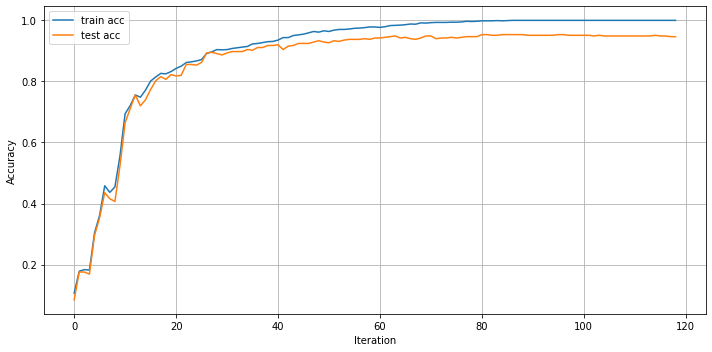

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(cb.train_acc, label="train acc")
ax.plot(cb.test_acc, label="test acc")
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

## Эксперименты с числом слоев (1 балл)

Ясно, что из-за случайного начального приближения с каждым запуском обучения мы будем получать различное качество. Попробуем обучить нашу нейросеть с разным числом слоев несколько раз.

Заполните матрицы `accs_train` и `accs_test`. В позиции `[i, j]` должна стоять величина доли правильных ответов сети с $i+1$ полносвязными слоями при $j$-м запуске (все запуски идентичны).

In [40]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [41]:
n_layers, n_runs = accs_train.shape

for layers_ in range(n_layers):
    for run_ in trange(n_runs, desc=f'n_layers = {layers_ + 1}'):
        #initializing
        network = make_network(input_size, hidden_layers_size,
                               output_size, layers_ + 1, ReLU)
        # fitting
        res = minimize(
            compute_loss_grad, get_weights(network),  
            args=[network, X_train, y_train], 
            method="L-BFGS-B",
            jac=True
        )
        # results
        accs_train[layers_, run_] = (predict(network, X_train) == y_train).mean()
        accs_test[layers_, run_] = (predict(network, X_test) == y_test).mean()

n_layers = 5: 100%|██████████| 5/5 [00:12<00:00,  2.49s/it]


Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

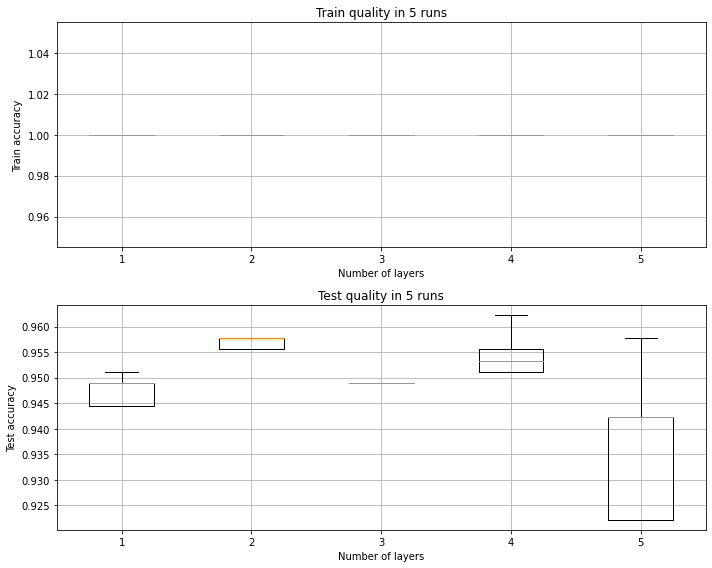

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].boxplot(accs_train.T, showfliers=False)
axes[1].boxplot(accs_test.T, showfliers=False)

axes[0].set_xlabel("Number of layers")
axes[1].set_xlabel("Number of layers")

axes[0].set_ylabel("Train accuracy")
axes[1].set_ylabel("Test accuracy")

axes[0].set_title("Train quality in 5 runs")
axes[1].set_title("Test quality in 5 runs")

axes[0].grid(True)
axes[1].grid(True)

fig.tight_layout()
plt.show()

In [43]:
accs_test

array([[0.94888889, 0.94444444, 0.95111111, 0.94888889, 0.94444444],
       [0.95555556, 0.94666667, 0.95777778, 0.95777778, 0.96444444],
       [0.94888889, 0.94666667, 0.96222222, 0.94888889, 0.94888889],
       [0.95555556, 0.95333333, 0.95111111, 0.96222222, 0.92222222],
       [0.94222222, 0.94222222, 0.08444444, 0.92222222, 0.95777778]])

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как изменяются качество на обучении и контроле и устойчивость процесса обучения при увеличении числа слоев?
* Можно ли сказать, что логистическая регрессия (линейная модель) дает качество хуже, чем нелинейная модель?

__Ответы:__

* Качество на обучении идеальное: NN переобучается. При росте числа слоёв увеличивается число параметров, то есть NN становится сложнее. На тесте качество возрастает до оптимального при 2-х слоях. При большем числе слоёв качество падает до наименьшего при 5-ти слоях.

* Логистическая модель наименьший разброс (из-за простоты модели), у неё хорошее качество (с 1-м слоем лучше, чем с 5-ю). То есть логистиечкая регрессия в ряде случаев даёт качество лучше, чем нелинейная модель.

## Эксперименты c различными инициализациями весов (1 балл)

Как уже было сказано, начальная инициализация весов нейронной сети может сильно влиять на процесс ее обучения и, как следствие, на ее качество.

В этом пункте вам предлагается попробовать обучить несколько нейронных сетей с различными инициализациями слоев.

Для этого необходимо реализовать функцию, инициализирующую веса линейных слоёв нашей нейронной сети. Добавьте в функционал данного метода возможность инициализировать его веса с помощью инициализации Kaiming (используется, если в нейронной сети в качестве функций активации используется ReLU) и инициализации Xavier (используется, если в нейронной сети в качестве функций активации используется Tanh или Sigmoid):

* Kaiming $\sim \mathcal{N}(0, \frac{2}{input\_units})$

* Xavier $\sim \mathcal{U}(-\sqrt{\frac{6}{input\_units + output\_units}}, \sqrt{\frac{6}{input\_units + output\_units}})$

In [44]:
def initialize_network(network, initialization):
    for layer in network:
        if isinstance(layer, Dense):
            input_units, output_units = layer.weights.shape
            if initialization == 'Kaiming':
                layer.weights = np.random.normal(scale=np.sqrt(2 / input_units),
                                                 size=(input_units, output_units))
            elif initialization == 'Xavier':
                bound = np.sqrt(6 / (input_units + output_units))
                layer.weights = np.random.uniform(low=-bound, high=bound,
                                                  size=(input_units, output_units))
            else:
                # Initialize weights with small random numbers from normal distribution.
                # In this case `initialization` represents a standard deviation
                # for normal distribution.
                layer.weights = np.random.randn(input_units, output_units) * initialization
            layer.biases = np.zeros_like(layer.biases)
            
            layer.params = [layer.weights, layer.biases]

Теперь попробуйте для каждой из 3 инициализаций обучить нейронную сеть несколько раз. Попробуйте проделать данную операцию при зафиксированном числе слоев равным 3, 4 и 5.

### 3 слоя

Зафиксируйте в сети число слоев равное трем.

Заполните матрицы `accs_train` и `accs_test`. В позиции `[i, j]` должна стоять величина доли правильных ответов сети при $j$-м запуске (все запуски идентичны) с инициализацией Kaiming при $i = 3$, с инициализацией Xavier при $i = 4$ и с инициализацией из нормального распределения с фиксированными параметрами при $0 \leqslant i \leqslant 2$ (попробуйте здесь 3 разных параметра для стандартного отклонения для нормального распределения, например: `1e-3`, `1e-2`, `1e-1`). Заметьте, что при большом числе слоев слишком низкое стандартное отклонение может не давать нейронной сети нормально обучиться.

In [45]:
init_vars = [1e-3, 1e-2, 1e-1, 'Kaiming', 'Xavier']

In [46]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [47]:
inits, n_runs = accs_train.shape

for init_ in range(inits):
    for run_ in trange(n_runs, desc=f'init_weights = "{init_vars[init_]}"'):
        #initializing network
        network = make_network(input_size, hidden_layers_size,
                               output_size, 3, ReLU)
        #initializing weights
        initialize_network(network, init_vars[init_])
        # fitting
        res = minimize(
            compute_loss_grad, get_weights(network),  
            args=[network, X_train, y_train], 
            method="L-BFGS-B",
            jac=True
        )
        # results
        accs_train[init_, run_] = (predict(network, X_train) == y_train).mean()
        accs_test[init_, run_] = (predict(network, X_test) == y_test).mean()

init_weights = "Xavier": 100%|██████████| 5/5 [00:02<00:00,  2.19it/s]


Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

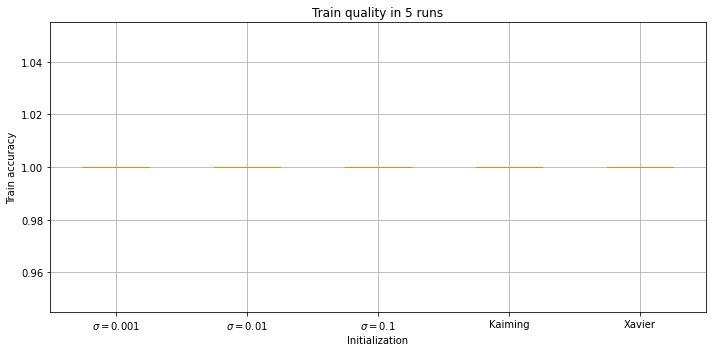

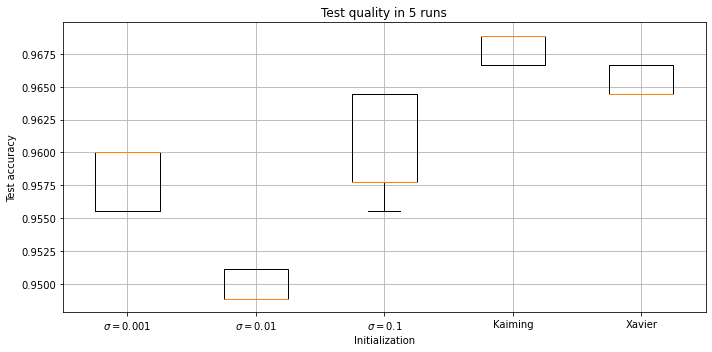

In [48]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_train.T, labels=init_vars_for_plot, showfliers=False)

ax.set_title("Train quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Train accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_test.T, labels=init_vars_for_plot, showfliers=False)

ax.set_title("Test quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Test accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

### 4 слоя

Выполните тут тот же код, что и в предыдущем пункте, но только уже с 4 слоями в сети.

In [49]:
init_vars = [5e-3, 1e-2, 1e-1, 'Kaiming', 'Xavier']

In [50]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [51]:
inits, n_runs = accs_train.shape

for init_ in range(inits):
    for run_ in trange(n_runs, desc=f'init_weights = "{init_vars[init_]}"'):
        #initializing network
        network = make_network(input_size, hidden_layers_size,
                               output_size, 4, ReLU)
        #initializing weights
        initialize_network(network, init_vars[init_])
        # fitting
        res = minimize(
            compute_loss_grad, get_weights(network),  
            args=[network, X_train, y_train], 
            method="L-BFGS-B",
            jac=True
        )
        # results
        accs_train[init_, run_] = (predict(network, X_train) == y_train).mean()
        accs_test[init_, run_] = (predict(network, X_test) == y_test).mean()

init_weights = "Xavier": 100%|██████████| 5/5 [00:03<00:00,  1.41it/s]


Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

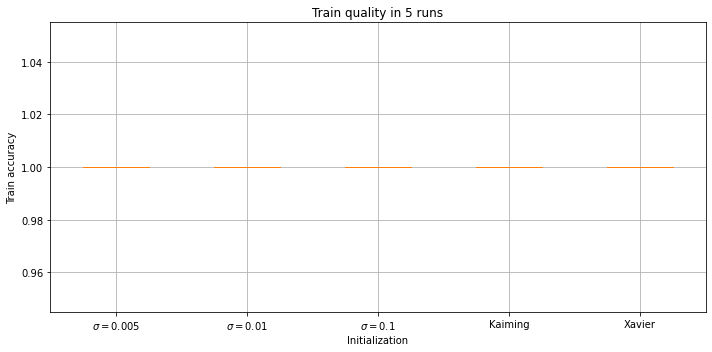

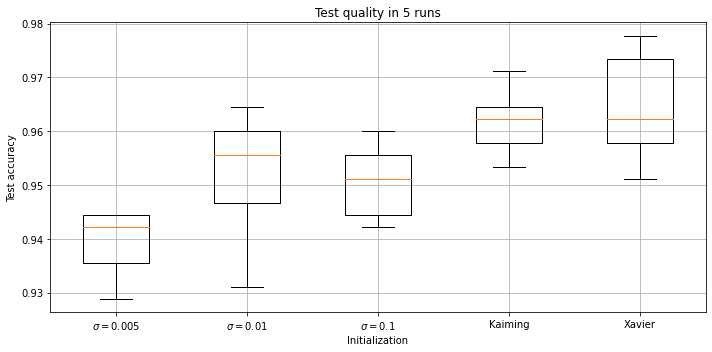

In [52]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_train.T, labels=init_vars_for_plot, showfliers=False)

ax.set_title("Train quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Train accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_test.T, labels=init_vars_for_plot, showfliers=False)

ax.set_title("Test quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Test accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

### 5 слоев

Выполните тут тот же код, что и в предыдущем пункте, но только уже с 5 слоями в сети.

In [53]:
init_vars = [1e-2, 1e-1, 1e0, 'Kaiming', 'Xavier']

In [54]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [55]:
inits, n_runs = accs_train.shape

for init_ in range(inits):
    for run_ in trange(n_runs, desc=f'init_weights = "{init_vars[init_]}"'):
        #initializing network
        network = make_network(input_size, hidden_layers_size,
                               output_size, 5, ReLU)
        #initializing weights
        initialize_network(network, init_vars[init_])
        # fitting
        res = minimize(
            compute_loss_grad, get_weights(network),  
            args=[network, X_train, y_train], 
            method="L-BFGS-B",
            jac=True
        )
        # results
        accs_train[init_, run_] = (predict(network, X_train) == y_train).mean()
        accs_test[init_, run_] = (predict(network, X_test) == y_test).mean()

init_weights = "Xavier": 100%|██████████| 5/5 [00:05<00:00,  1.07s/it]


Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

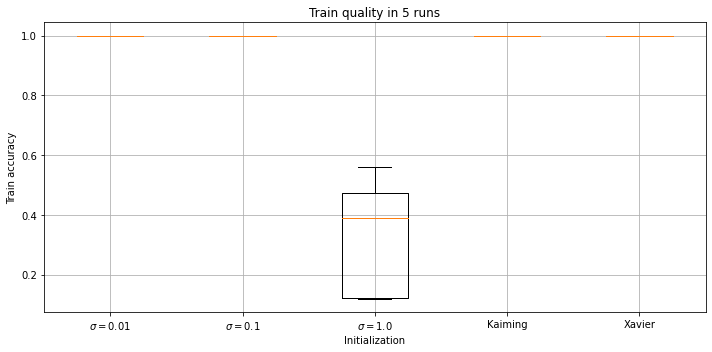

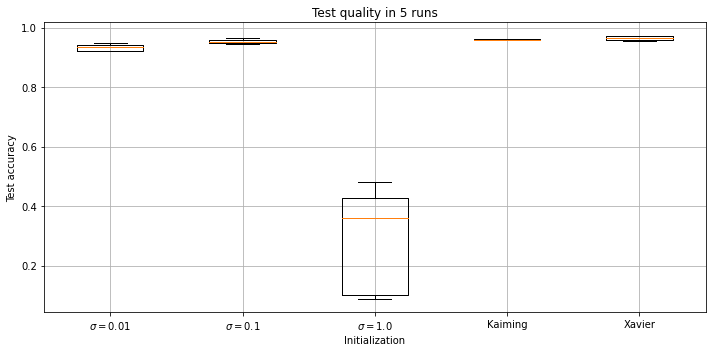

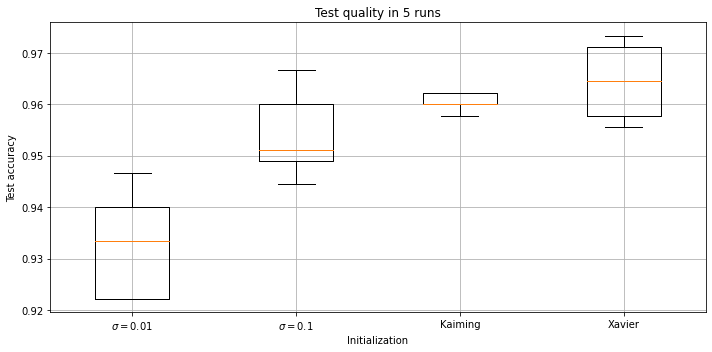

In [56]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_train.T, labels=init_vars_for_plot, showfliers=False)

ax.set_title("Train quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Train accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_test.T, labels=init_vars_for_plot, showfliers=False)

ax.set_title("Test quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Test accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()


fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(np.delete(accs_test, 2, axis=0).T, labels=init_vars_for_plot[:2]
           + init_vars_for_plot[3:], showfliers=False)

ax.set_title("Test quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Test accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как отличаются качество на обучении и контроле и устойчивость процесса обучения при различных инициализациях?
* Какие инициализации помогают обучать более глубокие сети?

__Ответы:__

* На обучении качество почти всегда идеальное, кроме "вырожденного" случая (5 слоёв и $\sigma = 1.0$), данная инициализация оказалась неудачной. Более устойчивое обучение получается при инициализациях Kaiming и Xavier.
* Разброс Kaiming и Xavier меньше, чем в среднем при других инициализациях. Особенно это заметно при увеличении слоёв (сравнение 3 и 4 слоёв), то есть для глубоких NN желательно применять инициализацию весов Kaiming и Xavier.

Теперь сравним скорость обучения при различных инициализациях. Создайте два списка списков `accs_test_on_iterations`, `accs_train_on_iterations` в каждом из которых в позиции `[i]` (см. описание `i` в предыдущем пункте) будет лежать список из значений `accuracy` на тестовой и обучающей выборках соотвественно, полученных во время обучения модели. Количество слоев в сети зафиксируйте равным 4.

##### Внимание! Я добавил 5e-3, потому что не при 1e-3 NN не обучается.

In [57]:
init_vars = [1e-3, 5e-3, 1e-2, 1e-1, 'Kaiming', 'Xavier']

In [58]:
accs_test_on_iterations = []
accs_train_on_iterations = []

In [59]:
inits = len(init_vars)

for init_ in trange(inits):
    #initializing network
    network = make_network(input_size, hidden_layers_size,
                            output_size, 4, ReLU)
    #initializing weights
    initialize_network(network, init_vars[init_])
    # callback for recording accuracy through iterations
    cb_ = Callback(network, X_train, y_train, X_test, y_test, print=False)
    # fitting
    res = minimize(
        compute_loss_grad, get_weights(network),  
        args=[network, X_train, y_train], 
        method="L-BFGS-B",
        jac=True,
        callback = cb_.call
    )
    # results
    accs_train_on_iterations += [cb_.train_acc]
    accs_test_on_iterations += [cb_.test_acc]

100%|██████████| 6/6 [00:08<00:00,  1.37s/it]


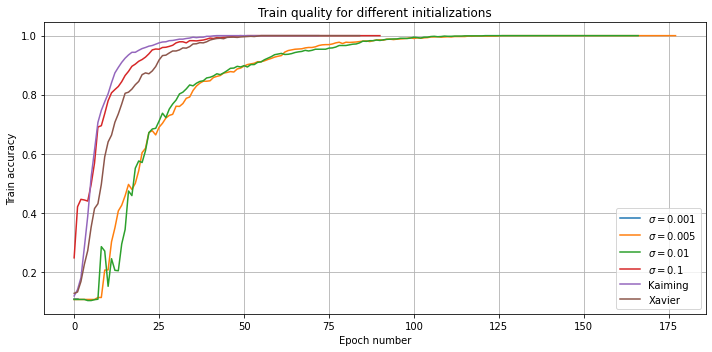

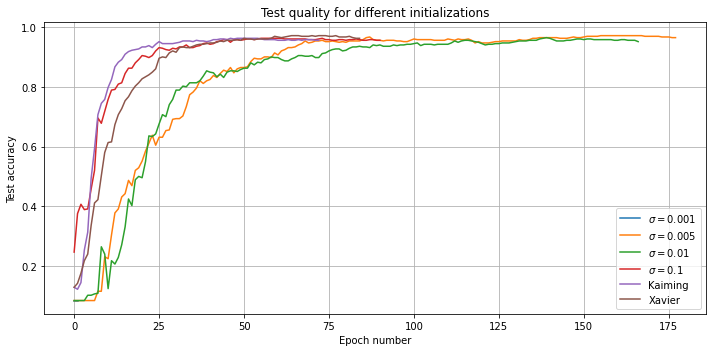

In [60]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for idx, label in enumerate(init_vars_for_plot):
    ax.plot(accs_train_on_iterations[idx], label=label)

ax.set_title("Train quality for different initializations")
ax.set_xlabel("Epoch number")
ax.set_ylabel("Train accuracy")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for idx, label in enumerate(init_vars_for_plot):
    ax.plot(accs_test_on_iterations[idx], label=label)

ax.set_title("Test quality for different initializations")
ax.set_xlabel("Epoch number")
ax.set_ylabel("Test accuracy")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как меняется скорость обучения в зависимости от выбранной инициализации?

__Ответы:__

Kaiming и Xavier достигают хорошего качества быстрее всего, но Kaiming, выйдя на плато, сходится быстрее. Инициализации разбросами $\sigma$ сходятся медленнее и итоговое качество хуже, чем на Kaiming и Xavier. При уменьшении $\sigma$ выход на плато проиходит медленнее. А при слишком малом разбросе ($\sigma = 0.001$) NN не обучилась вообще.

## Эксперименты c различными функциями активации (1 балл)

Проверим теперь, с какой функцией активации нейронная сеть будет обучаться лучше.

В этом пункте вам предлагается попробовать обучить несколько нейронных сетей с различными функциями активации.

Для этого нам нужно реализовать еще 2 слоя: для функций активации `Tanh` и `Sigmoid`.

$$
f = tanh(y); \; y, f \in \mathbb{R} ^ {bs \times n} \\
\frac{\partial f}{\partial y_{ij}} = tanh'(y_{ij}) = 1 - tanh^2(y_{ij}) \\
\frac{\partial \mathcal{L}}{\partial y} = \frac{\partial \mathcal{L}}{\partial f}\frac{\partial f}{\partial y} \Rightarrow \frac{\partial \mathcal{L}}{\partial y_{ij}} = \frac{\partial \mathcal{L}}{\partial f}\frac{\partial f}{\partial y_{ij}} = \frac{\partial \mathcal{L}}{\partial f} \left(1 - tanh^2(y_{ij})\right) \\
\frac{\partial \mathcal{L}}{\partial y} = \frac{\partial \mathcal{L}}{\partial f} \circ \left(E_{bs \times n} - tanh^2(y)\right)
$$

In [61]:
class Tanh:
    """
    tanh(y) = (e^y - e^(-y)) / (e^y + e^(-y))
    Используйте функцию np.tanh для подсчета гиперболического тангенса.
    Вы можете сами реализовать подсчет tanh, но тогда вам нужно устойчиво его вычислять.
    """
    def __init__(self):
        self.params = [] # Tanh has no parameters

    def forward(self, input):
        """
        Apply elementwise Tanh to [batch, num_units] matrix
        """
        self.input = input
        self.output = np.tanh(input)
        return self.output

    def backward(self, grad_output):
        """
        Compute gradient of loss w.r.t. Tanh input
        grad_output shape: [batch, num_units]
        output 1 shape: [batch, num_units]
        output 2: []
        """
        # broadcasting: 1 instead of E_{bs x n}
        return grad_output * (1 - self.output ** 2), []

    def __repr__(self):
        return 'Tanh()'

$$
f = \sigma(y) = \frac{1}{1 + e^{-y}}; \; y, f \in \mathbb{R} ^ {bs \times n} \\
\frac{\partial f}{\partial y_{ij}} = \sigma'(y_{ij}) = \sigma(y_{ij})\left(1 - \sigma(y_{ij})\right) \\
\frac{\partial \mathcal{L}}{\partial y} = \frac{\partial \mathcal{L}}{\partial f}\frac{\partial f}{\partial y} \Rightarrow \frac{\partial \mathcal{L}}{\partial y_{ij}} = \frac{\partial \mathcal{L}}{\partial f}\frac{\partial f}{\partial y_{ij}} = \frac{\partial \mathcal{L}}{\partial f} \left(\sigma(y_{ij})\left(1 - \sigma(y_{ij})\right)\right) \\
\frac{\partial \mathcal{L}}{\partial y} = \frac{\partial \mathcal{L}}{\partial f} \circ \sigma(y) \circ \left(E_{bs \times n} - \sigma(y)\right)
$$

In [62]:
from scipy.special import expit
    
class Sigmoid:
    """
    sigmoid(y) = 1 / (1 + e^(-y))
    Используйте функцию expit для подсчета сигмоиды.
    Вы можете сами реализовать подсчет сигмоиды, но тогда вам нужно устойчиво ее вычислять.
    """
    def __init__(self):
        self.params = [] # Sigmoid has no parameters

    def forward(self, input):
        """
        Apply elementwise Sigmoid to [batch, num_units] matrix
        """
        self.input = input
        self.output = expit(input)
        return self.output

    def backward(self, grad_output):
        """
        Compute gradient of loss w.r.t. Sigmoid input
        grad_output shape: [batch, num_units]
        output 1 shape: [batch, num_units]
        output 2: []
        """
        # broadcasting: 1 instead of E_{bs x n}
        return grad_output * self.output * (1 - self.output), []

    def __repr__(self):
        return 'Sigmoid()'

Теперь попробуйте для каждой из 3 функций активации обучить нейронную сеть несколько раз. Число слоев зафиксируйте равным 3. В случае `Tanh` и `Sigmoid` используйте инициализацию `Xavier`, а в случае `ReLU` используйте инициализацию `Kaiming`.

Заполните матрицы `accs_train` и `accs_test`. В позиции `[i, j]` должна стоять величина доли правильных ответов сети при $j$-м запуске (все запуски идентичны) с функцией активации $ReLU$ при $i = 0$, с функцией активации $Tanh$ при $i = 1$ и с функцией активации $Sigmoid$ при $i = 2$.

In [63]:
act_func_vars = ['Tanh', 'Sigmoid', 'ReLU']
init_for_act_funcs = ['Xavier', 'Xavier', 'Kaiming']
act_func_arr = [Tanh, Sigmoid, ReLU]

In [64]:
accs_train = np.zeros((3, 5))
accs_test = np.zeros((3, 5))

In [65]:
act_names, n_runs = accs_train.shape

for i in range(act_names):
    for run_ in trange(n_runs, desc=f'act. function = {act_func_vars[i]}'):
        #initializing network
        network = make_network(input_size, hidden_layers_size,
                               output_size, 3, act_func_arr[i])
        #initializing weights
        initialize_network(network, init_for_act_funcs[i])
        # fitting
        res = minimize(
            compute_loss_grad, get_weights(network),  
            args=[network, X_train, y_train], 
            method="L-BFGS-B",
            jac=True
        )
        # results
        accs_train[i, run_] = (predict(network, X_train) == y_train).mean()
        accs_test[i, run_] = (predict(network, X_test) == y_test).mean()

act. function = ReLU: 100%|██████████| 5/5 [00:02<00:00,  2.47it/s]


Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

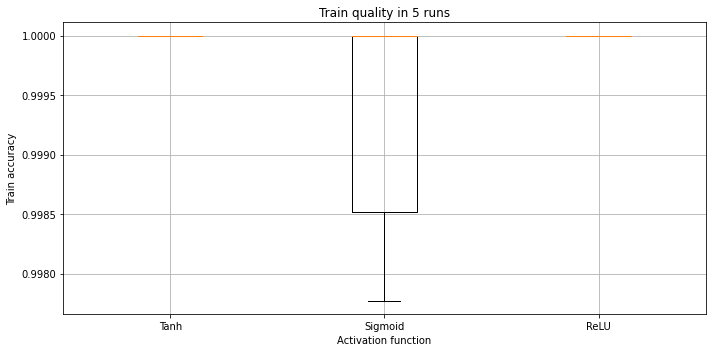

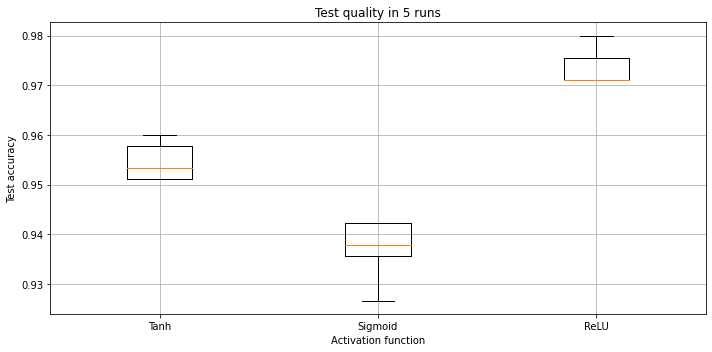

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_train.T, labels=act_func_vars, showfliers=False)

ax.set_title("Train quality in 5 runs")
ax.set_xlabel("Activation function")
ax.set_ylabel("Train accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_test.T, labels=act_func_vars, showfliers=False)

ax.set_title("Test quality in 5 runs")
ax.set_xlabel("Activation function")
ax.set_ylabel("Test accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как отличаются качество на обучении и контроле и устойчивость процесса обучения при различных функциях активации?

__Ответы:__

На обучении все функции активации имеют идеальное качество, только у $Sigmoid$ большой разброс. На тесте наилучшее качество, наибольшая устойчивость и наименьший разброс у $ReLU$. Разбросы у $Tanh$ и $Sigmoid$ в несколько раз больше, а качество в среднем хуже.

\* Несколько фрагментов кода в задании написаны на основе материалов [курса по глубинному обучению на ФКН НИУ ВШЭ](https://www.hse.ru/ba/ami/courses/205504078.html)

## Бонусная часть

## Реализация метода оптимизации (1 балл)

Реализуйте сами метод оптимизации (аналог функции `minimize`) для рассмотренной выше архитектуры. В качестве метода оптимизации используйте SGD + momentum. Продемонстрируйте правильную работу метода оптимизации, сравните его работу с LBFGS-B. Сделайте выводы.

Сделаем сначала обычный SGD:

In [109]:
def my_sgd(grad_f, w, args=[], callback=None,
           lr_a = 0.1, lr_b = 0, tol=1e-5, max_iter=1000):
    prev_loss = 0
    i = 1
    while True:
        loss, dw = grad_f(w, args)
        w -= lr_a / i ** lr_b * dw
        if callback is not None:
            callback(w)
        if np.abs(loss - prev_loss) < tol or i >=10000:
            break
        prev_loss = loss
        i += 1

In [110]:
#initializing network
network = make_network(input_size, hidden_layers_size,
                        output_size, 3, ReLU)
#initializing weights
initialize_network(network, 'Kaiming')
# callback
cb = Callback(network, X_train, y_train, X_test, y_test, print=True)
# fitting
res = my_sgd(
    compute_loss_grad, get_weights(network),
    args=[network, X_train, y_train],
    lr_a = 0.08, lr_b = 0.5,
    callback=cb.call
)

Выходные данные были обрезаны до нескольких последних строк (5000).
Accuracy (Train / Test): 0.5679 / 0.5267
Accuracy (Train / Test): 0.5694 / 0.5267
Accuracy (Train / Test): 0.5702 / 0.5289
Accuracy (Train / Test): 0.5731 / 0.5333
Accuracy (Train / Test): 0.5761 / 0.5400
Accuracy (Train / Test): 0.5798 / 0.5400
Accuracy (Train / Test): 0.5791 / 0.5444
Accuracy (Train / Test): 0.5791 / 0.5444
Accuracy (Train / Test): 0.5813 / 0.5467
Accuracy (Train / Test): 0.5835 / 0.5467
Accuracy (Train / Test): 0.5880 / 0.5444
Accuracy (Train / Test): 0.5902 / 0.5444
Accuracy (Train / Test): 0.5932 / 0.5422
Accuracy (Train / Test): 0.5939 / 0.5444
Accuracy (Train / Test): 0.5947 / 0.5444
Accuracy (Train / Test): 0.5961 / 0.5467
Accuracy (Train / Test): 0.5969 / 0.5489
Accuracy (Train / Test): 0.5984 / 0.5511
Accuracy (Train / Test): 0.5969 / 0.5489
Accuracy (Train / Test): 0.6021 / 0.5511
Accuracy (Train / Test): 0.6050 / 0.5533
Accuracy (Train / Test): 0.6065 / 0.5556
Accuracy (Train / Test): 0.608

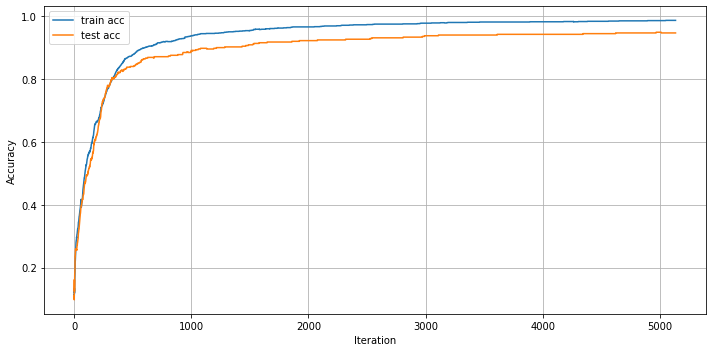

In [111]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(cb.train_acc, label="train acc")
ax.plot(cb.test_acc, label="test acc")
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

Итого, на обычном SGD получили $accuracy \approx 0.947$

Сделаем SGD Momentum:

In [130]:
def my_sgdm(grad_f, w, args=[], callback=None,
           v_a = 0.9, v_b = 0.1, tol=1e-5, max_iter=1000):
    prev_loss = 0
    v = 0
    i = 1
    while True:
        loss, dw = grad_f(w, args)
        v = v_b * v + (1 - v_b) * dw
        w = w - v_a * v #lr_a / i ** lr_b * dw
        if callback is not None:
            callback(w)
        if np.abs(loss - prev_loss) < tol or i >=10000:
            break
        prev_loss = loss
        i += 1

In [132]:
#initializing network
network = make_network(input_size, hidden_layers_size,
                        output_size, 3, ReLU)
#initializing weights
initialize_network(network, 'Kaiming')
# callback
cb = Callback(network, X_train, y_train, X_test, y_test, print=True)
# fitting
res = my_sgdm(
    compute_loss_grad, get_weights(network),
    args=[network, X_train, y_train],
    v_a = 0.1, v_b = 0.9,
    callback=cb.call
)

Accuracy (Train / Test): 0.1218 / 0.1267
Accuracy (Train / Test): 0.2019 / 0.1711
Accuracy (Train / Test): 0.2235 / 0.2178
Accuracy (Train / Test): 0.2970 / 0.2778
Accuracy (Train / Test): 0.2873 / 0.2689
Accuracy (Train / Test): 0.2569 / 0.2356
Accuracy (Train / Test): 0.2717 / 0.2489
Accuracy (Train / Test): 0.3437 / 0.3111
Accuracy (Train / Test): 0.4180 / 0.3511
Accuracy (Train / Test): 0.4202 / 0.3667
Accuracy (Train / Test): 0.4128 / 0.3978
Accuracy (Train / Test): 0.4491 / 0.4289
Accuracy (Train / Test): 0.5071 / 0.4689
Accuracy (Train / Test): 0.5345 / 0.5067
Accuracy (Train / Test): 0.5798 / 0.5556
Accuracy (Train / Test): 0.6548 / 0.6022
Accuracy (Train / Test): 0.6875 / 0.6244
Accuracy (Train / Test): 0.6964 / 0.6400
Accuracy (Train / Test): 0.7268 / 0.6556
Accuracy (Train / Test): 0.7580 / 0.6911
Accuracy (Train / Test): 0.7669 / 0.7111
Accuracy (Train / Test): 0.7617 / 0.7111
Accuracy (Train / Test): 0.7654 / 0.7200
Accuracy (Train / Test): 0.7817 / 0.7311
Accuracy (Train 

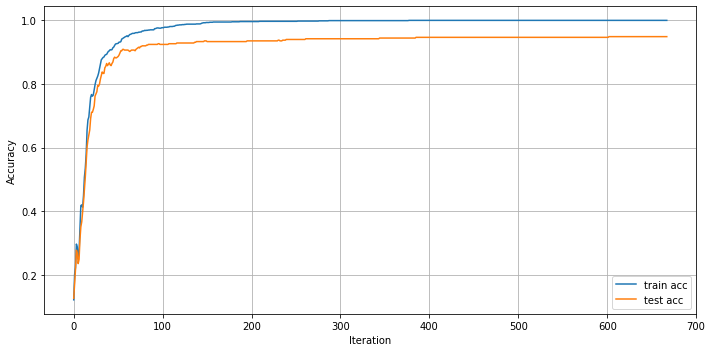

In [133]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(cb.train_acc, label="train acc")
ax.plot(cb.test_acc, label="test acc")
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

SGD Momentum даёт $accuracy \approx 0.949$, и это без подборов оптимальных параметров.

Оставим `v_b = 0.9`, подберём `v_a`:

In [136]:
v_a_arr = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
acc_train_arr = []
acc_test_arr = []

for v_a_ in tqdm(v_a_arr):
    #initializing network
    network = make_network(input_size, hidden_layers_size,
                            output_size, 3, ReLU)
    #initializing weights
    initialize_network(network, 'Kaiming')
    # callback
    cb = Callback(network, X_train, y_train, X_test, y_test, print=False)
    # fitting
    res = my_sgdm(
        compute_loss_grad, get_weights(network),
        args=[network, X_train, y_train],
        v_a = v_a_, v_b = 0.9,
        callback=cb.call
    )
    acc_train_arr += [cb.train_acc]
    acc_test_arr += [cb.test_acc]

100%|██████████| 7/7 [02:53<00:00, 24.76s/it]


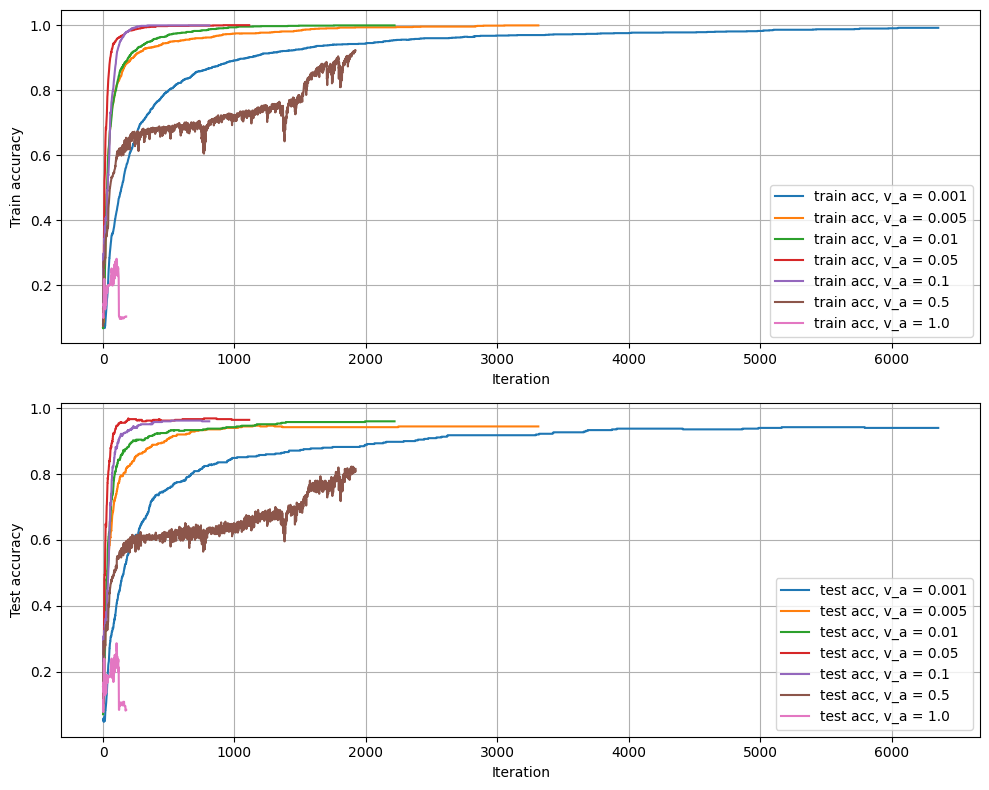

In [157]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=100)

for i, v_a in enumerate(v_a_arr):
    ax[0].plot(acc_train_arr[i], label=f"train acc, v_a = {v_a}")
    ax[1].plot(acc_test_arr[i], label=f"test acc, v_a = {v_a}")

ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Train accuracy")
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Test accuracy")
ax[1].grid(True)
ax[1].legend()

fig.tight_layout()
plt.show()

In [154]:
for lst, v_a in zip(acc_test_arr, v_a_arr):
    print(f'v_a = {v_a} best accuracy = {max(lst):.4f}')

v_a = 0.001 best accuracy = 0.9422
v_a = 0.005 best accuracy = 0.9467
v_a = 0.01 best accuracy = 0.9600
v_a = 0.05 best accuracy = 0.9689
v_a = 0.1 best accuracy = 0.9622
v_a = 0.5 best accuracy = 0.8222
v_a = 1.0 best accuracy = 0.2867


То есть при `v_a=0.05`, `v_b=0.9` с помощью своего SGDM имеем качество $\approx 0.969$. Учитывая, что максимальное качество приходится на `v_a=0.05` и `v_a=0.1`, возьмём, например, `v_a=0.055` в SGDM.

Теперь сравним этот метод с LBFGS-B. Сравниваем на 3-х слойной NN с ReLU.

In [212]:
acc_train_arr = []
acc_test_arr = []

In [213]:
#initializing network
network = make_network(input_size, hidden_layers_size,
                        output_size, 3, ReLU)
#initializing weights
initialize_network(network, 'Kaiming')
# callback
cb_1 = Callback(network, X_train, y_train, X_test, y_test, print=True)
# fitting
res = minimize(
    compute_loss_grad, get_weights(network),  
    args=[network, X_train, y_train], 
    method="L-BFGS-B",
    jac=True,
    callback=cb_1.call
)
acc_train_arr += [cb_1.train_acc] 
acc_test_arr += [cb_1.test_acc]

Accuracy (Train / Test): 0.0624 / 0.0733
Accuracy (Train / Test): 0.1024 / 0.1267
Accuracy (Train / Test): 0.1819 / 0.1933
Accuracy (Train / Test): 0.2442 / 0.2133
Accuracy (Train / Test): 0.2866 / 0.2356
Accuracy (Train / Test): 0.4172 / 0.3844
Accuracy (Train / Test): 0.5709 / 0.5511
Accuracy (Train / Test): 0.6236 / 0.6133
Accuracy (Train / Test): 0.7268 / 0.6578
Accuracy (Train / Test): 0.7602 / 0.7089
Accuracy (Train / Test): 0.7713 / 0.7422
Accuracy (Train / Test): 0.8070 / 0.7622
Accuracy (Train / Test): 0.8196 / 0.7889
Accuracy (Train / Test): 0.8515 / 0.8267
Accuracy (Train / Test): 0.8671 / 0.8467
Accuracy (Train / Test): 0.8872 / 0.8756
Accuracy (Train / Test): 0.9102 / 0.8889
Accuracy (Train / Test): 0.9191 / 0.8956
Accuracy (Train / Test): 0.9295 / 0.9067
Accuracy (Train / Test): 0.9332 / 0.9089
Accuracy (Train / Test): 0.9406 / 0.9089
Accuracy (Train / Test): 0.9451 / 0.9089
Accuracy (Train / Test): 0.9510 / 0.9267
Accuracy (Train / Test): 0.9547 / 0.9267
Accuracy (Train 

In [214]:
#initializing network
network = make_network(input_size, hidden_layers_size,
                        output_size, 3, ReLU)
#initializing weights
initialize_network(network, 'Kaiming')
# callback
cb_2 = Callback(network, X_train, y_train, X_test, y_test, print=True)
# fitting
res = my_sgdm(
    compute_loss_grad, get_weights(network),
    args=[network, X_train, y_train],
    v_a = 0.05, v_b = 0.9,
    callback=cb_2.call
)
acc_train_arr += [cb_2.train_acc] 
acc_test_arr += [cb_2.test_acc]

Accuracy (Train / Test): 0.0824 / 0.0822
Accuracy (Train / Test): 0.0750 / 0.0822
Accuracy (Train / Test): 0.0698 / 0.0889
Accuracy (Train / Test): 0.1188 / 0.1089
Accuracy (Train / Test): 0.1700 / 0.1822
Accuracy (Train / Test): 0.2220 / 0.2356
Accuracy (Train / Test): 0.2717 / 0.2311
Accuracy (Train / Test): 0.2710 / 0.2422
Accuracy (Train / Test): 0.2450 / 0.2222
Accuracy (Train / Test): 0.2494 / 0.2289
Accuracy (Train / Test): 0.2598 / 0.2222
Accuracy (Train / Test): 0.2791 / 0.2622
Accuracy (Train / Test): 0.3229 / 0.3044
Accuracy (Train / Test): 0.3764 / 0.3400
Accuracy (Train / Test): 0.4328 / 0.4000
Accuracy (Train / Test): 0.4870 / 0.4578
Accuracy (Train / Test): 0.5137 / 0.4978
Accuracy (Train / Test): 0.5278 / 0.5156
Accuracy (Train / Test): 0.5271 / 0.5311
Accuracy (Train / Test): 0.5308 / 0.5467
Accuracy (Train / Test): 0.5427 / 0.5644
Accuracy (Train / Test): 0.5553 / 0.5578
Accuracy (Train / Test): 0.5805 / 0.5733
Accuracy (Train / Test): 0.6080 / 0.5844
Accuracy (Train 

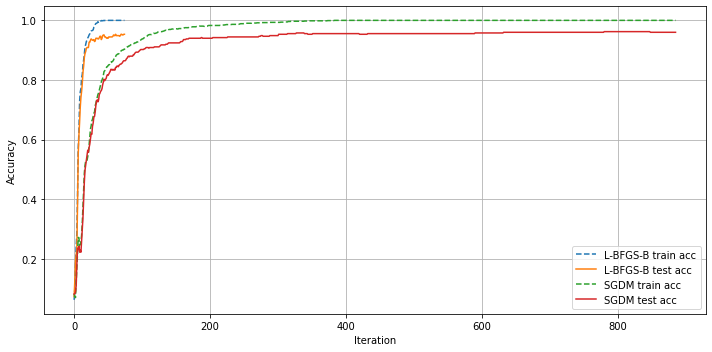

In [215]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for i, name in enumerate(['L-BFGS-B', 'SGDM']):
    ax.plot(acc_train_arr[i], '--', label=f'{name} train acc')
    ax.plot(acc_test_arr[i], label=f'{name} test acc')

ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

In [221]:
print(f'L-BFGS-B test acc: {acc_test_arr[0][-1]:.4f}, SGDM test acc: {acc_test_arr[1][-1]:.4f}')

L-BFGS-B test acc: 0.9533, SGDM test acc: 0.9600


SGDM сходится медленнее, а качество сравнимо с L-BFGS-B. В данном случае SGDM выигрывает у L-BFGS-B по качеству, но проигрывает по времени. А вообще SGDM достаточно распространён для оптимизации в NN.

## Dropout (1 балл) 

Реализуйте слой Dropout. Сравните обучение сети из большого числа слоёв при использовании Dropout и без его использования (предварительно подберите адекватный параметр $p$). Сделайте выводы.

Реализуем Inverted Dropout:

In [227]:
class Dropout:
    """
    Turn off activation on train with probability p
    """
    def __init__(self, p=0.5):
        """
        Initializing
        """
        self.p = p
        self.params = []
        self.inference_mode = False

    def forward(self, input):
        """
        Dropping out only on train
        input shape: [batch, num_units]
        output shape: [batch, num_units]
        """
        # test
        if self.inference_mode:
            return input
        #train
        self.drop = (np.random.uniform(0, 1, input.shape) > self.p) / (1 - self.p)
        return input * self.drop

    def backward(self, grad_output):
        """
        Computing gradients
        grad_output shape: [batch, num_units]
        output shapes: [batch, num_units], []
        """
        if not self.inference_mode:
            return self.drop * grad_output, []
        assert 0, 'Not inference mode!'
    
    def __repr__(self):
        return 'Dropout()'

Создадим удобный для тестирования класс Callback_Inference (перед подсчётом качества отключим в NN `inference_mode`, а после отключим):

In [242]:
class Callback_Inference:
    def __init__(self, network, X_train, y_train, X_test, y_test, print=False):
        self.network = network
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.print = print
        self.train_acc = []
        self.test_acc = []
        self.iters = 0
        
    def call(self, weights):
        """
        Computes quality on train and test set with given weights
        and saves to self.train_acc and self.test_acc.
        If self.print is True, also prints these 2 values
        """
        self.iters += 1
        # inference start
        for layer in self.network:
            layer.inference_mode = True
        # quality
        self.train_acc += [(predict(self.network, self.X_train) == self.y_train).mean()]
        self.test_acc += [(predict(self.network, self.X_test) == self.y_test).mean()]
        # inference end
        for layer in self.network:
            layer.inference_mode = False
        #print
        if self.print:
            print(f'{self.iters}. Accuracy (Train / Test): {self.train_acc[-1]:.4f} / {self.test_acc[-1]:.4f}')

Теперь создадим несколько NN для экспериментов. После первой активации будет основной Dropout, а после остальных активаций будет Dropout в 3 раза слабее:

In [272]:
p_arr = [0, 0.2, 0.5, 0.8]
nn_names = ['no DO', 'p=0.2', 'p=0.5', 'p=0.8']
hidden_layers_ = 2
weaker_DO_times = 3
nn_arr = []

for i, p_ in enumerate(p_arr):
    nn = []
    if (p_ > 0):
        nn += [Dense(input_size, hidden_layers_size), ReLU(), Dropout(p=p_)]
    else:
        nn += [Dense(input_size, hidden_layers_size), ReLU()]
    for i in range(hidden_layers_):
        if (p_ > 0):
            nn += ([Dense(hidden_layers_size, hidden_layers_size), ReLU(),
                    Dropout(p=p_/weaker_DO_times)])
        else:
            nn += [Dense(hidden_layers_size, hidden_layers_size), ReLU()]
    nn += [Dense(hidden_layers_size, output_size), LogSoftmax()]
    nn_arr.append(nn)
nn_arr

[[Dense(64, 32),
  Relu(),
  Dense(32, 32),
  Relu(),
  Dense(32, 32),
  Relu(),
  Dense(32, 10),
  LogSoftmax()],
 [Dense(64, 32),
  Relu(),
  Dropout(),
  Dense(32, 32),
  Relu(),
  Dropout(),
  Dense(32, 32),
  Relu(),
  Dropout(),
  Dense(32, 10),
  LogSoftmax()],
 [Dense(64, 32),
  Relu(),
  Dropout(),
  Dense(32, 32),
  Relu(),
  Dropout(),
  Dense(32, 32),
  Relu(),
  Dropout(),
  Dense(32, 10),
  LogSoftmax()],
 [Dense(64, 32),
  Relu(),
  Dropout(),
  Dense(32, 32),
  Relu(),
  Dropout(),
  Dense(32, 32),
  Relu(),
  Dropout(),
  Dense(32, 10),
  LogSoftmax()]]

Инициализируем подготовленные NN. Зафиксируем `random seed` для репрезентативности.

In [273]:
np.random.seed(0)

In [274]:
for nn_ in nn_arr:
    print(nn_)

[Dense(64, 32), Relu(), Dense(32, 32), Relu(), Dense(32, 32), Relu(), Dense(32, 10), LogSoftmax()]
[Dense(64, 32), Relu(), Dropout(), Dense(32, 32), Relu(), Dropout(), Dense(32, 32), Relu(), Dropout(), Dense(32, 10), LogSoftmax()]
[Dense(64, 32), Relu(), Dropout(), Dense(32, 32), Relu(), Dropout(), Dense(32, 32), Relu(), Dropout(), Dense(32, 10), LogSoftmax()]
[Dense(64, 32), Relu(), Dropout(), Dense(32, 32), Relu(), Dropout(), Dense(32, 32), Relu(), Dropout(), Dense(32, 10), LogSoftmax()]


In [277]:
acc_train_arr = []
acc_test_arr = []

for nn_, name_ in zip(nn_arr, nn_names):
    # initializing
    initialize_network(nn_, 'Kaiming')
    # callback
    cb_ = Callback_Inference(nn_, X_train, y_train, X_test, y_test, name_)
    # fitting
    print(f'=====NN {name_}=====')
    res = minimize(
        compute_loss_grad, get_weights(nn_),
        args=[nn_, X_train, y_train],
        method="L-BFGS-B",
        jac=True,
        callback=cb_.call,
    )
    print('================')
    # results
    acc_train_arr.append(cb_.train_acc)
    acc_test_arr.append(cb_.test_acc)

=====NN no DO=====
1. Accuracy (Train / Test): 0.0958 / 0.0978
2. Accuracy (Train / Test): 0.1047 / 0.1111
3. Accuracy (Train / Test): 0.1180 / 0.1222
4. Accuracy (Train / Test): 0.1767 / 0.1956
5. Accuracy (Train / Test): 0.2294 / 0.2267
6. Accuracy (Train / Test): 0.3022 / 0.2689
7. Accuracy (Train / Test): 0.4284 / 0.3844
8. Accuracy (Train / Test): 0.4929 / 0.4600
9. Accuracy (Train / Test): 0.5412 / 0.4978
10. Accuracy (Train / Test): 0.6600 / 0.6533
11. Accuracy (Train / Test): 0.7491 / 0.7067
12. Accuracy (Train / Test): 0.7654 / 0.7267
13. Accuracy (Train / Test): 0.7996 / 0.7667
14. Accuracy (Train / Test): 0.8218 / 0.7822
15. Accuracy (Train / Test): 0.8486 / 0.8133
16. Accuracy (Train / Test): 0.8634 / 0.8156
17. Accuracy (Train / Test): 0.8745 / 0.8422
18. Accuracy (Train / Test): 0.8924 / 0.8756
19. Accuracy (Train / Test): 0.9109 / 0.8844
20. Accuracy (Train / Test): 0.9347 / 0.8978
21. Accuracy (Train / Test): 0.9451 / 0.9089
22. Accuracy (Train / Test): 0.9607 / 0.9289


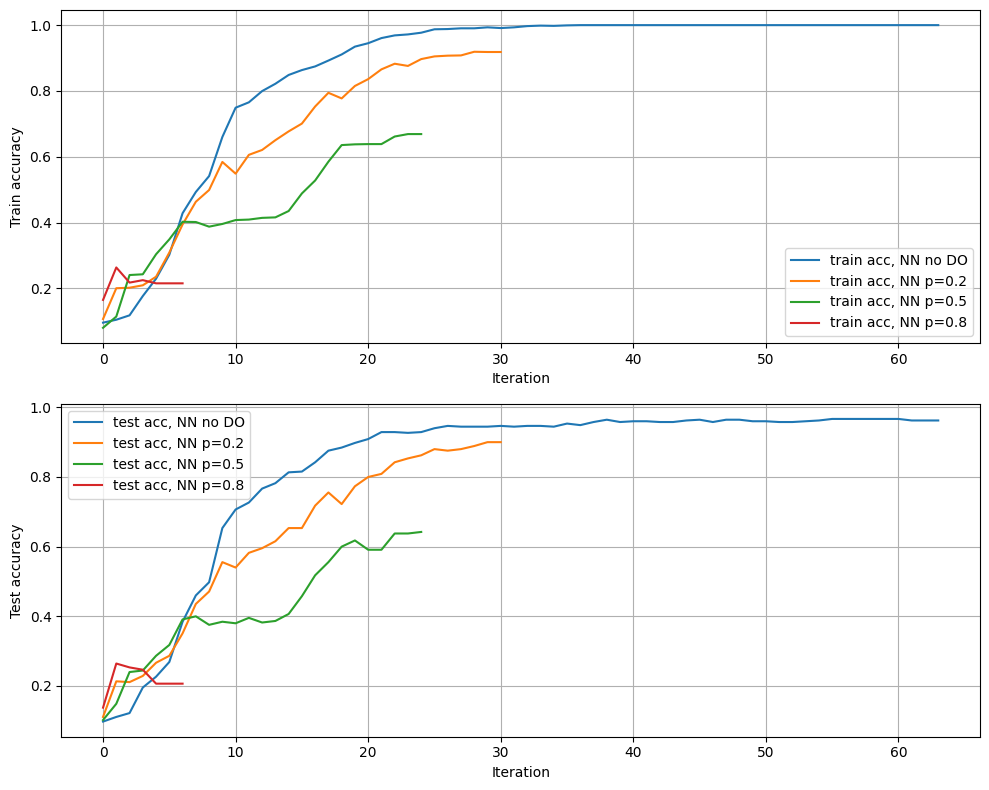

In [278]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), dpi=100)

for i, name_ in enumerate(nn_names):
    ax[0].plot(acc_train_arr[i], label=f"train acc, NN {name_}")
    ax[1].plot(acc_test_arr[i], label=f"test acc, NN {name_}")

ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Train accuracy")
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Test accuracy")
ax[1].grid(True)
ax[1].legend()

fig.tight_layout()
plt.show()

**Итого**: получили, что NN без DO работает лучше, и она работает тем хуже, чем больше вероятность отключения нейрона. Значит, рассматриваемые NN не переобучаются на этих данных и применение регуляризации Dropout избыточно, здесь это только ухудшает модель.

## BatchNormalization (1 балл)

Реализуйте слой `BatchNormalization`. Сравните обучение сети из большого числа слоёв при использовании `BatchNormalization` и без его использования. Сделайте выводы.